In [12]:
import pandas as pd

# Read the CSV file from GitHub
url_temp = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
url_torn = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_torn.csv"
url_hurrican = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_hurricane.csv"
url_typhoon = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.WP.list.v04r01.csv"
df_temp = pd.read_csv(url_temp)
df_torn = pd.read_csv(url_torn)
df_hurr = pd.read_csv(url_hurrican)
df_typh = pd.read_csv(url_typhoon)
print(df_temp.head())
print(df_torn .head())
print(df_hurr.head())
print(df_typh.head())



C:\Users\gregg\AppData\Local\Temp\ipykernel_56564\4275248124.py:11: DtypeWarning: Columns (1,2,8,9,14,19,20,23,24,142,143,144,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_typh = pd.read_csv(url_typhoon)


   Year  No_Smoothing  Lowess(30)
0  1880         -0.17       -0.21
1  1881         -0.09       -0.21
2  1882         -0.11       -0.21
3  1883         -0.17       -0.22
4  1884         -0.28       -0.22
    om    yr  mo  dy        date      time  tz  st  stf  stn  ...   len  wid  \
0  192  1950  10   1   10/1/1950  21:00:00   3  OK   40   23  ...  15.8   10   
1  193  1950  10   9   10/9/1950   2:15:00   3  NC   37    9  ...   2.0  880   
2  195  1950  11  20  11/20/1950   2:20:00   3  KY   21    1  ...   0.1   10   
3  196  1950  11  20  11/20/1950   4:00:00   3  KY   21    2  ...   0.1   10   
4  197  1950  11  20  11/20/1950   7:30:00   3  MS   28   14  ...   2.0   37   

   ns  sn  sg   f1  f2  f3  f4  fc  
0   1   1   1   25   0   0   0   0  
1   1   1   1   47   0   0   0   0  
2   1   1   1  177   0   0   0   0  
3   1   1   1  209   0   0   0   0  
4   1   1   1  101   0   0   0   0  

[5 rows x 29 columns]
       name  year  month  day  hour   lat  long               status  

In [14]:
#Temp clean up
import re
import pandas as pd
import numpy as np


# --- BEFORE: quick report ---
print("Dataset shape (before):", df_temp.shape)
print("Columns (before):", list(df_temp.columns))
print("\nMissing values per column (before):")
print(df_temp.isnull().sum())

# --- Renaming: add exactly one 'temp_' prefix and normalize names ---
def _normalize(name: str) -> str:
    # trim, lower, replace non-alphanumerics with underscore, collapse edges
    return re.sub(r'[^0-9a-zA-Z]+', '_', str(name).strip().lower()).strip('_')

def _ensure_temp_prefix(name: str) -> str:
    n = _normalize(name)
    # remove any existing 'temp_' at the start, then add exactly one
    if n.startswith("temp_"):
        n = n[len("temp_"):]
    return "temp_" + n

df_temp = df_temp.rename(columns=_ensure_temp_prefix)

# --- AFTER: report ---
print("\nDataset shape (after):", df_temp.shape)
print("Columns (after):", list(df_temp.columns))
print("\nMissing values per column (after):")
print(df_temp.isnull().sum())
df_temp

Dataset shape (before): (145, 3)
Columns (before): ['Year', 'No_Smoothing', 'Lowess(30)']

Missing values per column (before):
Year            0
No_Smoothing    0
Lowess(30)      0
dtype: int64

Dataset shape (after): (145, 3)
Columns (after): ['temp_year', 'temp_no_smoothing', 'temp_lowess_30']

Missing values per column (after):
temp_year            0
temp_no_smoothing    0
temp_lowess_30       0
dtype: int64


,temp_year,temp_no_smoothing,temp_lowess_30
0,1880,-0.17,-0.21
1,1881,-0.09,-0.21
2,1882,-0.11,-0.21
3,1883,-0.17,-0.22
4,1884,-0.28,-0.22
...,...,...,...
140,2020,1.01,0.93
141,2021,0.85,0.95
142,2022,0.89,0.97
143,2023,1.17,0.99


In [16]:
#tornado file cleanup

# --- Annual wide table: total + counts by magnitude (one row per year) ---

# Bin magnitude: keep 0..5 as ints; everything else (NaN or -9) -> -1 "Unknown"
tornado_unique["mag_bin"] = np.where(
    (tornado_unique["mag"].notna()) & (tornado_unique["mag"] >= 0),
    tornado_unique["mag"].astype(int),
    -1
)

# Year (yr) × mag_bin counts; ensure all mag columns present
counts_wide = (
    tornado_unique
      .groupby(["yr", "mag_bin"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[-1, 0, 1, 2, 3, 4, 5], fill_value=0)
      .rename(columns={
          -1: "Mag_Unknown",
           0: "Mag0", 1: "Mag1", 2: "Mag2", 3: "Mag3", 4: "Mag4", 5: "Mag5"
      })
      .reset_index(names="Year")
)

# Totals
counts_wide["Total_Tornadoes"] = (
    counts_wide[["Mag_Unknown","Mag0","Mag1","Mag2","Mag3","Mag4","Mag5"]].sum(axis=1)
)
counts_wide["Total_Known"] = (
    counts_wide[["Mag0","Mag1","Mag2","Mag3","Mag4","Mag5"]].sum(axis=1)
)

# Optional: sort and reorder columns
counts_wide = counts_wide.sort_values("Year").loc[:, [
    "Year", "Total_Tornadoes", "Total_Known",
    "Mag_Unknown", "Mag0", "Mag1", "Mag2", "Mag3", "Mag4", "Mag5"
]].reset_index(drop=True)

counts_wide.head()

import re

torn_final = counts_wide.rename(
    columns=lambda c: "torn_" + re.sub(r'[^0-9a-zA-Z]+', '_', str(c).strip().lower()).strip('_')
)

# Quick check
print(list(torn_final.columns))

torn_final



NameError: name 'tornado_unique' is not defined

In [18]:
#hurrican cleanup


import re
import pandas as pd
import numpy as np

# ---------- LOAD ----------
df_hurr = pd.read_csv(url_hurrican)
df_hurr.columns = df_hurr.columns.str.strip()

# ---------- ALIASES: map different source column names to a standard set ----------
lower_map = {c.lower(): c for c in df_hurr.columns}
aliases = {
    "name":     ["name", "storm_name"],
    "year":     ["year", "season"],
    "status":   ["status", "storm_status"],
    "category": ["category", "usa_sshs", "sshs", "saffir_simpson"],
}

chosen = {}
for target, options in aliases.items():
    for opt in options:
        if opt in lower_map:
            chosen[target] = lower_map[opt]
            break

required = {"name", "year", "status", "category"}
missing_targets = [t for t in required if t not in chosen]
if missing_targets:
    raise KeyError(
        f"Could not find columns for: {missing_targets}. "
        f"Available columns: {list(df_hurr.columns)}"
    )

# ---------- TRIM & STANDARDIZE ----------
keep = [chosen[k] for k in ["name", "year", "status", "category"]]
out = (
    df_hurr[keep]
      .rename(columns={
          chosen["name"]: "name",
          chosen["year"]: "year",
          chosen["status"]: "status",
          chosen["category"]: "category",
      })
)

# Dtypes
out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
out["category"] = pd.to_numeric(out["category"], errors="coerce")  # keep NaN for unrated

# ---------- FILTER TO HURRICANES ----------
status_norm = out["status"].astype(str).str.strip().str.lower()
is_hurricane_status = (
    status_norm.str.contains("hurrican", na=False) |  # 'hurricane' / 'hurricanes'
    status_norm.isin({"hu", "h"})                     # code forms
)
is_hurricane_category = out["category"].between(1, 5, inclusive="both")
is_hurricane = is_hurricane_status & (is_hurricane_category | out["category"].isna())
hurr = out.loc[is_hurricane].copy()

# ---------- ONE ROW PER (year, name) AT MAX CATEGORY ----------
idx = (
    hurr.assign(_cat=hurr["category"].fillna(-1))  # -1 so NaN never wins max
        .groupby(["year", "name"])["_cat"]
        .idxmax()
)
top_per_storm = hurr.loc[idx].reset_index(drop=True)

# Clean category to Int64 (only 1..5)
cat_clean = pd.to_numeric(top_per_storm["category"], errors="coerce").astype("Int64")
cat_clean = cat_clean.where(cat_clean.between(1, 5), pd.NA)
top_per_storm = top_per_storm.assign(category=cat_clean)

# ---------- YEARLY TOTALS ----------
year_total = (
    top_per_storm.groupby("year", as_index=False)
                 .size()
                 .rename(columns={"year": "Year", "size": "Total_Hurricanes"})
)

# ---------- PER-CATEGORY COUNTS (Cat_1..Cat_5) ----------
cat_cols = [1, 2, 3, 4, 5]
year_cat = (
    top_per_storm.dropna(subset=["category"])
                 .groupby(["year", "category"], as_index=False)
                 .size()
                 .pivot(index="year", columns="category", values="size")
                 .reindex(columns=cat_cols, fill_value=0)  # ensure all cat columns
                 .reset_index()                            # bring 'year' back
)

# Fill and cast only category columns; rename nicely
for c in cat_cols:
    if c in year_cat.columns:
        year_cat[c] = year_cat[c].fillna(0).astype(int)

year_cat = (
    year_cat
        .rename(columns={c: f"Cat_{c}" for c in cat_cols})
        .rename(columns={"year": "Year"})
        .sort_values("Year")
        .reset_index(drop=True)
)

# ---------- MERGE TOTALS + CATEGORY COLUMNS ----------
hurr_year = (
    year_total.merge(year_cat, on="Year", how="left")
              .fillna(0)
)

# Make sure Cat_* are ints after the merge
for c in [f"Cat_{k}" for k in cat_cols]:
    if c in hurr_year.columns:
        hurr_year[c] = hurr_year[c].astype(int)

hurr_year = (
    hurr_year[["Year", "Total_Hurricanes", "Cat_1", "Cat_2", "Cat_3", "Cat_4", "Cat_5"]]
             .sort_values("Year")
             .reset_index(drop=True)
)

# ---------- ADD 'hurr_' PREFIX TO ALL OUTPUT COLUMNS ----------
def _hurr_prefix(name: str) -> str:
    n = re.sub(r'[^0-9a-zA-Z]+', '_', str(name).strip().lower()).strip('_')  # normalize
    n = re.sub(r'^(?:hurr_)+', '', n)  # prevent double prefix
    return f"hurr_{n}"

hurr_year = hurr_year.rename(columns=_hurr_prefix)

print(hurr_year.head())

   hurr_year  hurr_total_hurricanes  hurr_cat_1  hurr_cat_2  hurr_cat_3  \
0       1975                      6           1           2           2   
1       1976                      6           2           2           2   
2       1977                      5           4           0           0   
3       1978                      5           2           1           0   
4       1979                      5           2           1           0   

   hurr_cat_4  hurr_cat_5  
0           1           0  
1           0           0  
2           0           1  
3           2           0  
4           1           1  


In [20]:
###typhoon cleanup
# --- Load only what we need for filtering/deriving peak SSHS ---
usecols = ["SID","NAME","SEASON","BASIN","ISO_TIME","USA_WIND","WMO_WIND","USA_SSHS"]
df_typh = pd.read_csv(url_typhoon, usecols=usecols, low_memory=False)

# Coerce types
df_typh["SEASON"]   = pd.to_numeric(df_typh["SEASON"], errors="coerce").astype("Int64")
df_typh["USA_WIND"] = pd.to_numeric(df_typh["USA_WIND"], errors="coerce")
df_typh["WMO_WIND"] = pd.to_numeric(df_typh["WMO_WIND"], errors="coerce")
df_typh["USA_SSHS"] = pd.to_numeric(df_typh["USA_SSHS"], errors="coerce")
df_typh["ISO_TIME"] = pd.to_datetime(df_typh["ISO_TIME"], errors="coerce", utc=True)

# Filter: West Pacific + years
df_typh = df_typh[(df_typh["BASIN"] == "WP") & (df_typh["SEASON"].between(1975, 2024))].copy()

# Keep only storms that ever reached typhoon intensity (>= 64 kt by USA or WMO wind)
def reached_typhoon(g):
    return bool((g["USA_WIND"] >= 64).any() or (g["WMO_WIND"] >= 64).any())

ty_tracks = (
    df_typh.groupby("SID", group_keys=False)
           .filter(reached_typhoon)
           .sort_values(["SID","ISO_TIME"])
           .reset_index(drop=True)
)

# Helper: knots -> Saffir–Simpson category
def ss_cat(k):
    if pd.isna(k): return np.nan
    k = float(k)
    return 5 if k>=137 else 4 if k>=113 else 3 if k>=96 else 2 if k>=83 else 1 if k>=64 else 0

# Per-storm maxima
per_storm = (
    ty_tracks.groupby(["SID","NAME","SEASON"], as_index=False)
             .agg(max_usa_wind=("USA_WIND","max"),
                  max_wmo_wind=("WMO_WIND","max"),
                  max_usa_sshs=("USA_SSHS","max"))
)

# Prefer reported USA_SSHS; if NaN, derive from winds (USA then WMO)
per_storm["SSHS"] = per_storm["max_usa_sshs"]
m = per_storm["SSHS"].isna()
per_storm.loc[m, "SSHS"] = per_storm.loc[m, "max_usa_wind"].apply(ss_cat)
m = per_storm["SSHS"].isna()
per_storm.loc[m, "SSHS"] = per_storm.loc[m, "max_wmo_wind"].apply(ss_cat)

# Final trimmed table: only the columns you asked for
typhoon_simple = (
    per_storm.loc[:, ["NAME","SEASON","SSHS"]]
             .sort_values(["SEASON","NAME"])
             .reset_index(drop=True)
)

typhoon_simple


# --- One row per year with counts by SSHS category ---

# Ensure SSHS is integer categories 0..5 (drop NaN if any slipped through)
typhoon_simple["SSHS"] = pd.to_numeric(typhoon_simple["SSHS"], errors="coerce")

year_cat = (
    typhoon_simple
      .dropna(subset=["SSHS"])
      .assign(SSHS=lambda d: d["SSHS"].astype(int))
      .groupby(["SEASON", "SSHS"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[0,1,2,3,4,5], fill_value=0)   # ensure all category columns exist
      .rename(columns={0:"Cat0", 1:"Cat1", 2:"Cat2", 3:"Cat3", 4:"Cat4", 5:"Cat5"})
      .reset_index()
      .sort_values("SEASON")
)

# Optional: helpful totals
year_cat["Total_Typhoons"] = year_cat[["Cat0","Cat1","Cat2","Cat3","Cat4","Cat5"]].sum(axis=1)
year_cat["Major_Cat35"]    = year_cat[["Cat3","Cat4","Cat5"]].sum(axis=1)

# Reorder columns (Season first)
cols = ["SEASON","Total_Typhoons","Major_Cat35","Cat0","Cat1","Cat2","Cat3","Cat4","Cat5"]
year_cat = year_cat.loc[:, cols]

year_cat.head()

import re
typh_final = year_cat.rename(columns=lambda c: (
    "typh_" + re.sub(r'[^0-9a-zA-Z]+', '_', str(c).strip().lower()).strip('_')
    if not str(c).lower().startswith("hurr_")
    else str(c)
))

typh_final





C:\Users\gregg\AppData\Local\Temp\ipykernel_56564\2456797558.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_typh["ISO_TIME"] = pd.to_datetime(df_typh["ISO_TIME"], errors="coerce", utc=True)


SSHS,typh_season,typh_total_typhoons,typh_major_cat35,typh_cat0,typh_cat1,typh_cat2,typh_cat3,typh_cat4,typh_cat5
0,1975,14,5,0,6,3,1,3,1
1,1976,14,9,0,5,0,1,7,1
2,1977,11,4,0,4,3,1,3,0
3,1978,15,3,0,8,4,1,1,1
4,1979,14,8,0,2,4,4,2,2
5,1980,16,9,1,3,3,5,3,1
6,1981,16,6,0,5,5,2,3,1
7,1982,19,12,0,4,3,6,4,2
8,1983,13,6,1,5,1,0,3,3
9,1984,17,9,1,6,1,2,6,1


In [21]:
#joining all files

import pandas as pd
import numpy as np

def _prep_year_key(df, candidates):
    """Rename the first existing candidate to 'Year', coerce to Int64, dedupe per year."""
    found = None
    for c in candidates:
        if c in df.columns:
            found = c
            break
    if found is None:
        raise KeyError(f"None of the candidate year columns {candidates} found in: {list(df.columns)}")
    out = df.rename(columns={found: "Year"}).copy()
    out["Year"] = pd.to_numeric(out["Year"], errors="coerce").astype("Int64")
    out = out.dropna(subset=["Year"]).drop_duplicates(subset=["Year"], keep="last")
    return out

# 1) Normalize each table's join key to 'Year'
temp_k = _prep_year_key(df_temp,   ["temp_year", "year", "Year"])
torn_k = _prep_year_key(torn_final,["torn_year", "year", "Year"])
hurr_k = _prep_year_key(hurr_year, ["hurr_year", "year", "Year"])
typh_k = _prep_year_key(typh_final,["typh_season", "typh_Season", "season", "Season", "year", "Year"])

# 2) Merge (outer to keep all years present in any table)
merged = (
    temp_k.merge(torn_k, on="Year", how="outer", suffixes=(None, None))
          .merge(hurr_k, on="Year", how="outer")
          .merge(typh_k, on="Year", how="outer")
          .sort_values("Year")
          .reset_index(drop=True)
)

# 3) Optional: make sure non-Year numeric cols are numbers (won’t break strings)
for col in merged.columns:
    if col != "Year":
        merged[col] = pd.to_numeric(merged[col], errors="ignore")

# 4) Optional: fill NaNs for count-like columns with 0 (skip temp_* columns if you prefer)
count_like = [c for c in merged.columns if c != "Year" and not c.startswith("temp_")]
merged[count_like] = merged[count_like].fillna(0)

# 5) Put Year first, keep existing prefixed columns afterwards
cols = ["Year"] + [c for c in merged.columns if c != "Year"]
merged = merged.loc[:, cols]



merged = merged[pd.to_numeric(merged["Year"], errors="coerce").ge(1975)].copy()
merged = merged.sort_values("Year").reset_index(drop=True)

merged.head()
merged

NameError: name 'torn_final' is not defined

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# ===== Helpers ===============================================================
def pick_col(df, candidates):
    """Return the first column name that exists in df from candidates."""
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found. Available: {list(df.columns)}")

def lowess_series(x, y, years_span=30):
    """LOWESS smoother using a ~years_span window."""
    mask = np.isfinite(x) & np.isfinite(y)
    xs, ys = x[mask], y[mask]
    out = np.full_like(x, np.nan, dtype=float)
    if len(xs) >= 3:
        frac = min(1.0, years_span / max(len(np.unique(xs)), 1))
        out[mask] = lowess(ys, xs, frac=frac, return_sorted=False)
    return out

def add_trend_and_stats(ax, x, y):
    """Add linear trend line and a stats box (Slope / Avg / Median)."""
    m, b = np.polyfit(x, y, 1)                 # slope & intercept
    xx = np.array([x.min(), x.max()], float)
   # ax.plot(xx, m*xx + b, color="0.25", lw=1.2, alpha=0.9)

    txt = (
        f"Slope: {m:+.3f} per year\n"
        f"Avg/yr: {np.nanmean(y):,.3f}\n"
        f"Median/yr: {np.nanmedian(y):,.3f}"
    )
    ax.text(
        0.015, 0.985, txt,
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", lw=0.8, alpha=0.95),
        zorder=10,
    )

def plot_with_lowess(ax, year, series, title, ylabel):
    """One panel: black raw line, red LOWESS(30), gray trend, stats box."""
    year = pd.to_numeric(year, errors="coerce").to_numpy(float)
    series = pd.to_numeric(series, errors="coerce").to_numpy(float)
    mask = np.isfinite(year) & np.isfinite(series)
    x, y = year[mask], series[mask]

    # raw series + LOWESS
    ax.plot(x, y, color="black", lw=1.4, label="No_Smoothing")
    lo = lowess_series(x, y, years_span=30)
    ax.plot(x, lo[mask], color="red", lw=2.0, label="Lowess(30)")

    # linear trend + stats
    add_trend_and_stats(ax, x, y)

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper right", frameon=True)

# ===== Build data from `merged` =============================================
sns.set_theme(style="whitegrid")

df = merged.copy()
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df[df["Year"] >= 1975].sort_values("Year").reset_index(drop=True)

#col_temp = pick_col(df, ["temp_no_smoothing", "No_Smoothing"])
col_hurr = pick_col(df, ["hurr_total_hurricanes", "Total_Hurricanes"])
col_torn = pick_col(df, ["torn_total_tornadoes", "Total_Tornadoes"])
col_typh = pick_col(df, ["typh_total_typhoons", "Total_Typhoons"])

# ===== Plot 2×2 grid ========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

plot_with_lowess(axes[0], df["Year"], df[col_hurr], "Total Hurricanes per Year", "Hurricanes")
plot_with_lowess(axes[1], df["Year"], df[col_torn], "Total Tornadoes per Year", "Tornadoes")
plot_with_lowess(axes[2], df["Year"], df[col_typh], "Total Typhoons per Year", "Typhoons")

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- Prep ----------
df = merged.copy().sort_values("Year").reset_index(drop=True)

# Column names (robust to your prefixes)
col_year = "Year"
col_temp = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

series_cols = [
    ("Tornadoes",  "torn_total_tornadoes",  "Unique U.S. Tornadoes"),
    ("Hurricanes", "hurr_total_hurricanes", "U.S. Hurricanes"),
    ("Typhoons",   "typh_total_typhoons",   "West Pacific Typhoons")
]

# Build a long table: Year, Series, Count (keep only available series)
long_parts = []
titles = []  # panel titles matching order
for label, col, nice_title in series_cols:
    if col in df.columns:
        sub = df[[col_year, col]].dropna().rename(columns={col_year: "Year", col: "Count"})
        sub["Series"] = label
        # keep only finite counts
        sub = sub[np.isfinite(sub["Count"])]
        long_parts.append(sub)
        titles.append(nice_title)

if not long_parts:
    raise ValueError("None of the expected series columns were found in `merged`.")

long_df = pd.concat(long_parts, ignore_index=True)

# Temperature map across all years we actually plot
temp_map = df.set_index("Year")[col_temp]
plot_years = np.sort(long_df["Year"].unique())
temp_vals = temp_map.reindex(plot_years).to_numpy(dtype=float)
vmin, vmax = np.nanmin(temp_vals), np.nanmax(temp_vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (temp_vals - vmin) / rng

cmap = sns.color_palette("RdYlGn_r", as_cmap=True)  # green (cool) -> red (warm)
year_to_color = {
    int(y): (cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7))
    for y, t in zip(plot_years, norm_vals)
}

# ---------- Plot (3 facets) ----------
sns.set_theme(style="whitegrid")
n_panels = len(long_parts)
fig, axes = plt.subplots(1, n_panels, figsize=(6*n_panels+2, 5), sharey=False)

if n_panels == 1:
    axes = [axes]

for ax, (label, col, nice_title) in zip(axes, series_cols):
    if col not in df.columns:
        ax.set_visible(False)
        continue

    d = long_df[long_df["Series"] == label].sort_values("Year")
    years = d["Year"].to_numpy()
    counts = d["Count"].to_numpy()

    # Bars colored by temperature anomaly for that year
    colors = [year_to_color[int(y)] for y in years]
    x = np.arange(len(years))
    ax.bar(x, counts, color=colors, edgecolor="none")

    # Trend line (fit vs positions to match bars)
    m, b = np.polyfit(x.astype(float), counts.astype(float), 1)
    y_hat = m * x + b
    ax.plot(x, y_hat, color="gray", lw=1.0, label="Trend")

    # Titles/labels
    ax.set_title(f"{nice_title} per Year (1975+)", pad=10)
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")

    # Decade ticks (display real years while x uses positions)
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)

    # Small stats box
    avg_val = counts.mean()
    med_val = np.median(counts)
    ax.text(0.02, 0.96, f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}\nSlope: {m:+.2f}/yr",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9))

# One shared colorbar for temperature
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, fraction=0.05)
cbar.set_label("Temperature anomaly (°C)")
cbar.set_ticks(np.linspace(vmin, vmax, 6))
cbar.set_ticklabels([f"{t:.2f}" for t in np.linspace(vmin, vmax, 6)])

#plt.tight_layout()
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap)
sm.set_array([])

#cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.9, pad=0.02)
#cbar.set_label("Temperature anomaly (°C)")
#cbar.set_ticks(np.linspace(vmin, vmax, 6))
#cbar.set_ticklabels([f"{t:.2f}" for t in np.linspace(vmin, vmax, 6)])

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read dataset
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
df = pd.read_csv(url)

# Long format for seaborn
df_long = df.melt('Year', var_name='Series', value_name='Temperature')

# Plot
sns.set_theme(style="white")
custom_colors = {'No_Smoothing': 'black', 'Lowess(30)': 'red'}

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=df_long,
    x='Year', y='Temperature',
    hue='Series', style='Series',
    palette=custom_colors, markers=False, dashes=False, ax=ax
)
ax.set(
    ylabel='Temperature (°C)',
    xlabel='Year',
    title='Global Temperature Anomalies'
)

# ---- Stats (from raw No_Smoothing series) ----
raw = df[['Year', 'No_Smoothing']].dropna()
x = raw['Year'].to_numpy(dtype=float)
y = raw['No_Smoothing'].to_numpy(dtype=float)

# Linear slope (°C per year)
m, b = np.polyfit(x, y, 1)
avg = float(np.mean(y))
med = float(np.median(y))

# Optional: show the fitted line (comment out if you don't want it)
# ax.plot(x, m*x + b, color="0.4", lw=1.2, alpha=0.8, label="Trend")

# Stats box
text = (f"Slope: {m:+.3f} per year\n"
        f"Avg/yr: {avg:.3f}\n"
        f"Median/yr: {med:.3f}")
ax.text(
    0.015, 0.985, text,
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

plt.tight_layout()
plt.show()


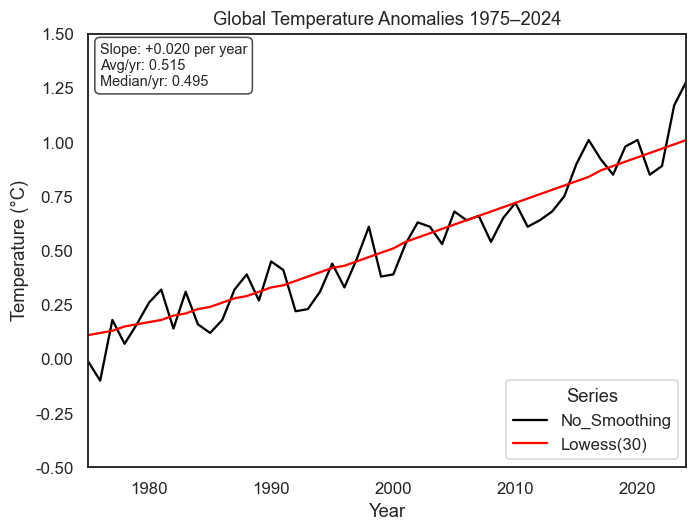

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read + filter
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
df = pd.read_csv(url)
df = df[(df["Year"] >= 1975) & (df["Year"] <= 2024)].copy()

# Long format for seaborn
df_long = df.melt("Year", var_name="Series", value_name="Temperature")

sns.set_theme(style="white")
custom_colors = {"No_Smoothing": "black", "Lowess(30)": "red"}

# 👉 Narrower figure (width ~6.5 inches)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=110)

import numpy as np
from matplotlib.ticker import FormatStrFormatter

# --- Y-axis: start at -0.25, ticks every 0.25, show two decimals ---
step = 0.25
y_min = -0.50
y_max = np.ceil(df["No_Smoothing"].max() / step) * step  # round up to next 0.25

ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, y_max + step/2, step))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


sns.lineplot(
    data=df_long, x="Year", y="Temperature",
    hue="Series", style="Series",
    palette=custom_colors, markers=False, dashes=False, ax=ax
)

ax.set(
    ylabel="Temperature (°C)",
    xlabel="Year",
    title="Global Temperature Anomalies 1975–2024"
)
ax.set_xlim(1975, 2024)

# Stats from No_Smoothing
raw = df[["Year", "No_Smoothing"]].dropna()
x = raw["Year"].to_numpy(float)
y = raw["No_Smoothing"].to_numpy(float)
m, b = np.polyfit(x, y, 1)
avg, med = float(np.mean(y)), float(np.median(y))

ax.text(
    0.02, 0.98,
    f"Slope: {m:+.3f} per year\nAvg/yr: {avg:.3f}\nMedian/yr: {med:.3f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

plt.tight_layout()
plt.show()


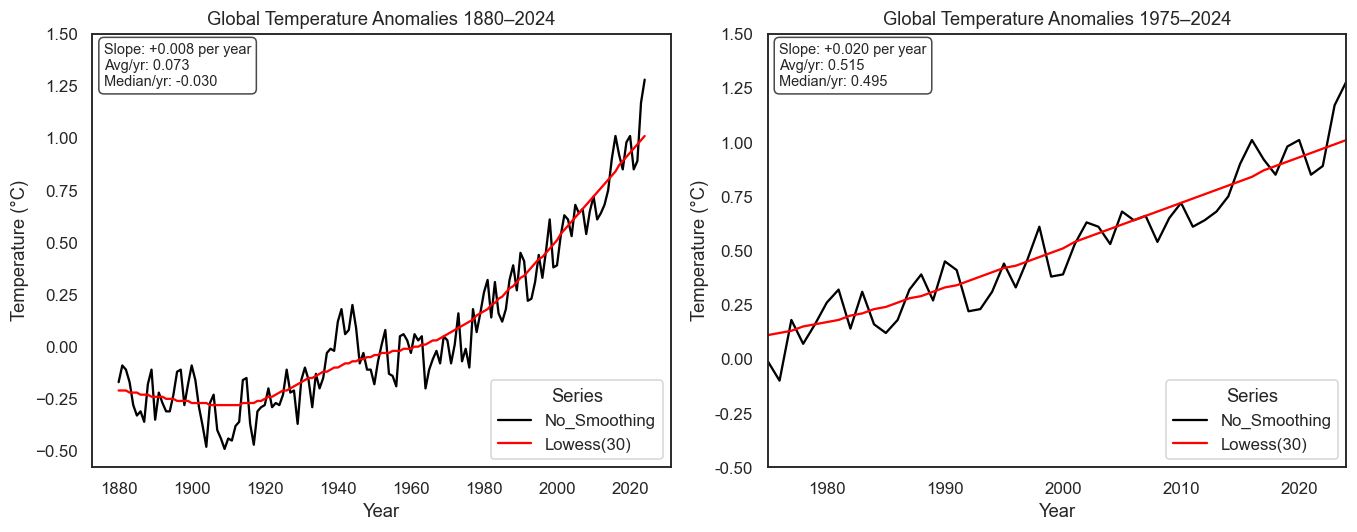

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- Read once ---
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
df = pd.read_csv(url)

# Versions of the data
df_filt = df[(df["Year"] >= 1975) & (df["Year"] <= 2024)].copy()

# Long format for seaborn
df_long_full = df.melt("Year", var_name="Series", value_name="Temperature")
df_long_filt = df_filt.melt("Year", var_name="Series", value_name="Temperature")

sns.set_theme(style="white")
custom_colors = {"No_Smoothing": "black", "Lowess(30)": "red"}

# --- Side-by-side figure (reversed order) ---
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12.5, 5), dpi=110)

# ===== LEFT panel: full series 1880–2024 (y max = 1.50) =====
sns.lineplot(
    data=df_long_full, x="Year", y="Temperature",
    hue="Series", style="Series",
    palette=custom_colors, markers=False, dashes=False, ax=ax_left
)
ax_left.set(
    ylabel="Temperature (°C)",
    xlabel="Year",
    title="Global Temperature Anomalies 1880–2024"
)
ax_left.set_ylim(ax_left.get_ylim()[0], 1.50)

# Stats (full period)
raw_full = df[["Year", "No_Smoothing"]].dropna()
xf = raw_full["Year"].to_numpy(float)
yf = raw_full["No_Smoothing"].to_numpy(float)
mf, bf = np.polyfit(xf, yf, 1)
avgf, medf = float(np.mean(yf)), float(np.median(yf))
ax_left.text(
    0.02, 0.98,
    f"Slope: {mf:+.3f} per year\nAvg/yr: {avgf:.3f}\nMedian/yr: {medf:.3f}",
    transform=ax_left.transAxes, ha="left", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

# ===== RIGHT panel: 1975–2024 with custom y ticks =====
sns.lineplot(
    data=df_long_filt, x="Year", y="Temperature",
    hue="Series", style="Series",
    palette=custom_colors, markers=False, dashes=False, ax=ax_right
)
ax_right.set(
    ylabel="Temperature (°C)",
    xlabel="Year",
    title="Global Temperature Anomalies 1975–2024"
)
ax_right.set_xlim(1975, 2024)

# Y-axis: start at -0.50, ticks every 0.25, two decimals
step = 0.25
y_min = -0.50
y_max = np.ceil(df_filt["No_Smoothing"].max() / step) * step
ax_right.set_ylim(y_min, y_max)
ax_right.set_yticks(np.arange(y_min, y_max + step/2, step))
ax_right.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Stats (filtered period)
raw = df_filt[["Year", "No_Smoothing"]].dropna()
x = raw["Year"].to_numpy(float)
y = raw["No_Smoothing"].to_numpy(float)
m, b = np.polyfit(x, y, 1)
avg, med = float(np.mean(y)), float(np.median(y))
ax_right.text(
    0.02, 0.98,
    f"Slope: {m:+.3f} per year\nAvg/yr: {avg:.3f}\nMedian/yr: {med:.3f}",
    transform=ax_right.transAxes, ha="left", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

plt.tight_layout()
plt.show()


In [30]:
import pandas as pd

# 1️⃣ Load the dataset directly from GitHub
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_torn.csv"
df = pd.read_csv(url)

# 2️⃣ Clean column names
df.columns = df.columns.str.strip()

# 3️⃣ Check for missing values (NaN or empty)
print("\n🔍 Missing Values by Column:")
print(df.isna().sum().sort_values(ascending=False))

# 4️⃣ Optionally: show % of missing values per column
print("\n📊 Percentage of Missing Values:")
print((df.isna().mean() * 100).round(2))

# 5️⃣ Identify rows with any missing values
missing_rows = df[df.isna().any(axis=1)]
print(f"\n⚠️ Total rows with at least one missing value: {len(missing_rows)}")

# 6️⃣ (Optional) Display the first few rows that contain missing data
if not missing_rows.empty:
    print("\nSample rows with missing data:")
    print(missing_rows.head())




🔍 Missing Values by Column:
om       0
slat     0
f4       0
f3       0
f2       0
f1       0
sg       0
sn       0
ns       0
wid      0
len      0
elon     0
elat     0
slon     0
closs    0
yr       0
loss     0
fat      0
inj      0
mag      0
stn      0
stf      0
st       0
tz       0
time     0
date     0
dy       0
mo       0
fc       0
dtype: int64

📊 Percentage of Missing Values:
om       0.0
yr       0.0
mo       0.0
dy       0.0
date     0.0
time     0.0
tz       0.0
st       0.0
stf      0.0
stn      0.0
mag      0.0
inj      0.0
fat      0.0
loss     0.0
closs    0.0
slat     0.0
slon     0.0
elat     0.0
elon     0.0
len      0.0
wid      0.0
ns       0.0
sn       0.0
sg       0.0
f1       0.0
f2       0.0
f3       0.0
f4       0.0
fc       0.0
dtype: float64

⚠️ Total rows with at least one missing value: 0


In [32]:
import pandas as pd

url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_torn.csv"
df = pd.read_csv(url)
print(df.columns.tolist())
print(df.head(5))


['om', 'yr', 'mo', 'dy', 'date', 'time', 'tz', 'st', 'stf', 'stn', 'mag', 'inj', 'fat', 'loss', 'closs', 'slat', 'slon', 'elat', 'elon', 'len', 'wid', 'ns', 'sn', 'sg', 'f1', 'f2', 'f3', 'f4', 'fc']
    om    yr  mo  dy        date      time  tz  st  stf  stn  ...   len  wid  \
0  192  1950  10   1   10/1/1950  21:00:00   3  OK   40   23  ...  15.8   10   
1  193  1950  10   9   10/9/1950   2:15:00   3  NC   37    9  ...   2.0  880   
2  195  1950  11  20  11/20/1950   2:20:00   3  KY   21    1  ...   0.1   10   
3  196  1950  11  20  11/20/1950   4:00:00   3  KY   21    2  ...   0.1   10   
4  197  1950  11  20  11/20/1950   7:30:00   3  MS   28   14  ...   2.0   37   

   ns  sn  sg   f1  f2  f3  f4  fc  
0   1   1   1   25   0   0   0   0  
1   1   1   1   47   0   0   0   0  
2   1   1   1  177   0   0   0   0  
3   1   1   1  209   0   0   0   0  
4   1   1   1  101   0   0   0   0  

[5 rows x 29 columns]


In [33]:
# Unique tornadoes per year
tornado_year = (
    df.drop_duplicates(subset=["yr", "om"])
      .groupby("yr", as_index=False)
      .size()
      .rename(columns={"yr": "Year", "size": "Tornadoes"})
      .sort_values("Year")
)

# ▶ Filter to 1975+
tornado_year = tornado_year[tornado_year["Year"] >= 1975].reset_index(drop=True)

tornado_year

,Year,Tornadoes
0,1975,919
1,1976,834
2,1977,852
3,1978,789
4,1979,855
5,1980,866
6,1981,782
7,1982,1047
8,1983,930
9,1984,907


Text(12.0, 427.058, 'Min 656 (1987)')

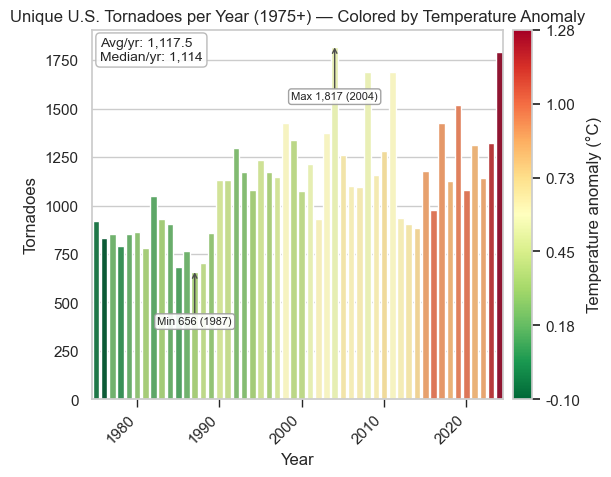

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns

# --- 1) Build a colormap from the temperature series ---
# Load temps (or reuse your existing `temp` DataFrame)
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
temp = pd.read_csv(url).rename(columns=str.strip)

# Use only years present in tornado_year
temp_map = temp.set_index("Year")["No_Smoothing"]
common_years = tornado_year["Year"]

vals = temp_map.reindex(common_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / rng

# green -> yellow -> red
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7)
                 for y, t in zip(common_years, norm)}

# --- 2) Bar chart of tornadoes colored by the temp gradient ---
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=tornado_year,
    x="Year",
    y="Tornadoes",
    hue="Year",                 # per-bar coloring by year
    palette=year_to_color,      # map year -> gradient color
    dodge=False,
    legend=False,
    errorbar=None
)

ax.set_title("Unique U.S. Tornadoes per Year (1975+) — Colored by Temperature Anomaly")
ax.set_xlabel("Year")
ax.set_ylabel("Tornadoes")
ax.set_ylim(bottom=0)

# Tick labels every 10 years starting 1980
years = tornado_year["Year"].tolist()
tick_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
tick_lab = [str(years[i]) for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lab, rotation=45, ha="right")
ax.tick_params(axis="x", which="major", length=6, width=1, bottom=True)

# Avg/Median box
avg_val = tornado_year["Tornadoes"].mean()
med_val = tornado_year["Tornadoes"].median()
ax.text(
    0.02, 0.98, f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
)

import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Colorbar that matches the bar colors ---
# Use the same vmin/vmax and cmap you used to color the bars
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap)
sm.set_array([])  # required for older Matplotlib versions

# Create the colorbar
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Temperature anomaly (°C)")

# Nice tick values across the observed range
tick_vals = np.linspace(vmin, vmax, 6)  # 6 ticks; tweak as you like
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{t:.2f}" for t in tick_vals])

# --- Label MAX/MIN tornado years (smaller font than axis labels) ---
import numpy as np

# --- Find max/min bars ---
counts = tornado_year["Tornadoes"].to_numpy()
years_s = tornado_year["Year"].to_numpy()
imax = int(np.argmax(counts))
imin = int(np.argmin(counts))

bar_max = ax.patches[imax]
bar_min = ax.patches[imin]

# Arrow targets: center-top of each bar
x_max = bar_max.get_x() + bar_max.get_width()/2
y_max = bar_max.get_height()
x_min = bar_min.get_x() + bar_min.get_width()/2
y_min = bar_min.get_height()

# Put labels LOWER than the bar tops
ylo, yhi = ax.get_ylim()
ydrop = 0.12 * (yhi - ylo)   # how far below the tip the label sits

label_max = f"Max {counts[imax]:,.0f} ({int(years_s[imax])})"
label_min = f"Min {counts[imin]:,.0f} ({int(years_s[imin])})"

common_annot_kws = dict(
    ha="center", va="top", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1, color="0.3", shrinkA=0, shrinkB=0)
)

# MAX: text lower, arrow up to bar tip
ax.annotate(label_max, xy=(x_max, y_max), xytext=(x_max, y_max - ydrop), **common_annot_kws)

# MIN: text lower, arrow up to bar tip
ax.annotate(label_min, xy=(x_min, y_min), xytext=(x_min, y_min - ydrop), **common_annot_kws)



Text(12.0, 427.058, 'Min 656 (1987)')

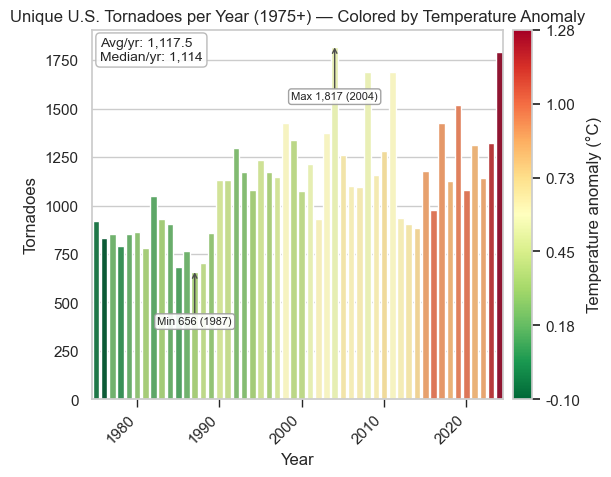

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns

# --- 1) Build a colormap from the temperature series ---
# Load temps (or reuse your existing `temp` DataFrame)
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
temp = pd.read_csv(url).rename(columns=str.strip)

# Use only years present in tornado_year
temp_map = temp.set_index("Year")["No_Smoothing"]
common_years = tornado_year["Year"]

vals = temp_map.reindex(common_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / rng

# green -> yellow -> red
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7)
                 for y, t in zip(common_years, norm)}

# --- 2) Bar chart of tornadoes colored by the temp gradient ---
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=tornado_year,
    x="Year",
    y="Tornadoes",
    hue="Year",                 # per-bar coloring by year
    palette=year_to_color,      # map year -> gradient color
    dodge=False,
    legend=False,
    errorbar=None
)

ax.set_title("Unique U.S. Tornadoes per Year (1975+) — Colored by Temperature Anomaly")
ax.set_xlabel("Year")
ax.set_ylabel("Tornadoes")
ax.set_ylim(bottom=0)

# Tick labels every 10 years starting 1980
years = tornado_year["Year"].tolist()
tick_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
tick_lab = [str(years[i]) for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lab, rotation=45, ha="right")
ax.tick_params(axis="x", which="major", length=6, width=1, bottom=True)

# Avg/Median box
avg_val = tornado_year["Tornadoes"].mean()
med_val = tornado_year["Tornadoes"].median()
ax.text(
    0.02, 0.98, f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
)

import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Colorbar that matches the bar colors ---
# Use the same vmin/vmax and cmap you used to color the bars
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap)
sm.set_array([])  # required for older Matplotlib versions

# Create the colorbar
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Temperature anomaly (°C)")

# Nice tick values across the observed range
tick_vals = np.linspace(vmin, vmax, 6)  # 6 ticks; tweak as you like
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{t:.2f}" for t in tick_vals])

# --- Label MAX/MIN tornado years (smaller font than axis labels) ---
import numpy as np

# --- Find max/min bars ---
counts = tornado_year["Tornadoes"].to_numpy()
years_s = tornado_year["Year"].to_numpy()
imax = int(np.argmax(counts))
imin = int(np.argmin(counts))

bar_max = ax.patches[imax]
bar_min = ax.patches[imin]

# Arrow targets: center-top of each bar
x_max = bar_max.get_x() + bar_max.get_width()/2
y_max = bar_max.get_height()
x_min = bar_min.get_x() + bar_min.get_width()/2
y_min = bar_min.get_height()

# Put labels LOWER than the bar tops
ylo, yhi = ax.get_ylim()
ydrop = 0.12 * (yhi - ylo)   # how far below the tip the label sits

label_max = f"Max {counts[imax]:,.0f} ({int(years_s[imax])})"
label_min = f"Min {counts[imin]:,.0f} ({int(years_s[imin])})"

common_annot_kws = dict(
    ha="center", va="top", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1, color="0.3", shrinkA=0, shrinkB=0)
)

# MAX: text lower, arrow up to bar tip
ax.annotate(label_max, xy=(x_max, y_max), xytext=(x_max, y_max - ydrop), **common_annot_kws)

# MIN: text lower, arrow up to bar tip
ax.annotate(label_min, xy=(x_min, y_min), xytext=(x_min, y_min - ydrop), **common_annot_kws)



In [40]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Colorbar that matches the bar colors ---
# Use the same vmin/vmax and cmap you used to color the bars
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap)
sm.set_array([])  # required for older Matplotlib versions

# Create the colorbar
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Temperature anomaly (°C)")

# Nice tick values across the observed range
tick_vals = np.linspace(vmin, vmax, 6)  # 6 ticks; tweak as you like
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{t:.2f}" for t in tick_vals])


<Figure size 640x480 with 0 Axes>

In [42]:
import pandas as pd
import numpy as np

MAG_COL = "mag"  # <-- if your magnitude field has a different name, change this

# ---------------------------
# Base: unique tornadoes per year (KEEPING your om dedupe)
# ---------------------------
tornado_year = (
    df.drop_duplicates(subset=["yr", "om"])
      .groupby("yr", as_index=False)
      .size()
      .rename(columns={"yr": "Year", "size": "Tornadoes"})
      .sort_values("Year")
)
tornado_year = tornado_year[tornado_year["Year"] >= 1975].reset_index(drop=True)

# ---------------------------
# Per-year counts by magnitude, using the SAME deduped rows
# ---------------------------
uniq = df.drop_duplicates(subset=["yr", "om"]).copy()
uniq["yr"] = pd.to_numeric(uniq["yr"], errors="coerce").astype("Int64")
if MAG_COL not in uniq.columns:
    raise KeyError(f"Expected a magnitude column named '{MAG_COL}'. Update MAG_COL if yours is different.")
uniq[MAG_COL] = pd.to_numeric(uniq[MAG_COL], errors="coerce")

# keep 1975+
uniq = uniq[uniq["yr"] >= 1975]

# count per (year, magnitude) from the deduped set
year_mag = (
    uniq.dropna(subset=[MAG_COL])                # drop rows with unknown magnitude only for mag counts
        .groupby(["yr", MAG_COL], as_index=False)
        .size()
        .rename(columns={"yr": "Year", "size": "Count"})
)

# pivot to wide (Mag_0..Mag_5)
mag_wide = (
    year_mag.pivot(index="Year", columns=MAG_COL, values="Count")
            .reindex(columns=[0, 1, 2, 3, 4, 5])   # ensure all six magnitude columns exist
            .fillna(0)
            .astype(int)
)
mag_wide.columns = [f"Mag_{int(c)}" for c in mag_wide.columns]

# ---------------------------
# Merge into tornado_year and align totals
# ---------------------------
tornado_year = tornado_year.merge(mag_wide, how="left", left_on="Year", right_index=True).fillna(0)

# total for that YEAR should equal the deduped total
mag_cols = [f"Mag_{i}" for i in range(6)]
tornado_year["Total_Tornadoes_Year"] = tornado_year["Tornadoes"].astype(int)

# (optional) if you want integers for mag columns
tornado_year[mag_cols] = tornado_year[mag_cols].astype(int)

tornado_year


,Year,Tornadoes,Mag_0,Mag_1,Mag_2,Mag_3,Mag_4,Mag_5,Total_Tornadoes_Year
0,1975,919,307,376,191,34,11,0,919
1,1976,834,241,361,168,48,13,3,834
2,1977,852,236,420,136,48,11,1,852
3,1978,789,338,312,106,26,7,0,789
4,1979,855,359,342,116,31,7,0,855
5,1980,866,267,400,162,32,5,0,866
6,1981,782,283,320,149,23,7,0,782
7,1982,1047,374,421,187,58,6,1,1047
8,1983,930,350,372,147,57,4,0,930
9,1984,907,373,352,126,41,14,1,907


In [45]:
import numpy as np
import pandas as pd

# starting from your tornado_year (already filtered to Year >= 1975)
start_base = 1975
max_year = int(tornado_year["Year"].max())

# compute 5-year period boundaries and a label
period_start = ((tornado_year["Year"] - start_base) // 5) * 5 + start_base
period_end = np.minimum(period_start + 4, max_year)

tornado_year = tornado_year.assign(
    Period_Start = period_start.astype(int),
    Period_End   = period_end.astype(int),
)
tornado_year["Period"] = tornado_year["Period_Start"].astype(str) + "–" + tornado_year["Period_End"].astype(str)

# aggregate: average & median tornadoes per year within each 5-year bin
df_5yr = (
    tornado_year
      .groupby(["Period_Start","Period_End","Period"], as_index=False)
      .agg(
          Avg_Tornadoes   = ("Tornadoes", "mean"),
          Median_Tornadoes= ("Tornadoes", "median"),
          Years_in_Bin    = ("Year", "nunique")
      )
      .sort_values("Period_Start")
)

# (optional) tidy types / rounding
df_5yr["Avg_Tornadoes"] = df_5yr["Avg_Tornadoes"].round(1)
df_5yr["Median_Tornadoes"] = df_5yr["Median_Tornadoes"].round(0).astype(int)

df_5yr

,Period_Start,Period_End,Period,Avg_Tornadoes,Median_Tornadoes,Years_in_Bin
0,1975,1979,1975–1979,849.8,852,5
1,1980,1984,1980–1984,906.4,907,5
2,1985,1989,1985–1989,732.6,702,5
3,1990,1994,1990–1994,1163.4,1133,5
4,1995,1999,1995–1999,1264.0,1236,5
5,2000,2004,2000–2004,1282.6,1214,5
6,2005,2009,2005–2009,1261.2,1156,5
7,2010,2014,2010–2014,1140.4,938,5
8,2015,2019,2015–2019,1244.8,1177,5
9,2020,2024,2020–2024,1330.2,1314,5


In [47]:
import numpy as np
import pandas as pd

# -------- pick the magnitude column robustly --------
mag_candidates = ["mag", "MAG", "f_scale", "Fscale", "fscale"]
MAG_COL = next((c for c in mag_candidates if c in df.columns), None)
if MAG_COL is None:
    raise ValueError("Couldn't find a magnitude column. Expected one of: " + ", ".join(mag_candidates))

# -------- your yearly counts (unchanged) --------
tornado_year = (
    df.drop_duplicates(subset=["yr", "om"])  # om = per-tornado ordinal; keep 1 per tornado per year
      .groupby("yr", as_index=False)
      .size()
      .rename(columns={"yr": "Year", "size": "Tornadoes"})
      .sort_values("Year")
)
tornado_year = tornado_year[tornado_year["Year"] >= 1975].reset_index(drop=True)

# -------- helper to compute 5-year periods --------
START_BASE = 1975
max_year = int(tornado_year["Year"].max())

pstart = ((tornado_year["Year"] - START_BASE) // 5) * 5 + START_BASE
pend   = np.minimum(pstart + 4, max_year)

tornado_year = tornado_year.assign(
    Period_Start = pstart.astype(int),
    Period_End   = pend.astype(int),
)
tornado_year["Period"] = tornado_year["Period_Start"].astype(str) + "–" + tornado_year["Period_End"].astype(str)

# -------- avg & median per 5-year period (from yearly counts) --------
df_5yr = (
    tornado_year
      .groupby(["Period_Start","Period_End","Period"], as_index=False)
      .agg(
          Avg_Tornadoes    = ("Tornadoes", "mean"),
          Median_Tornadoes = ("Tornadoes", "median"),
          Years_in_Bin     = ("Year", "nunique")
      )
      .sort_values("Period_Start")
)

# -------- total event COUNTS by magnitude (0..5) per 5-year period --------
# Use raw rows and the REAL magnitude column (MAG_COL); DO NOT drop_duplicates here.
work = df.dropna(subset=["yr", MAG_COL]).copy()
work["yr"]  = pd.to_numeric(work["yr"],  errors="coerce").astype("int64")
work[MAG_COL] = pd.to_numeric(work[MAG_COL], errors="coerce").astype("int64")
work = work[(work["yr"] >= START_BASE) & (work[MAG_COL].between(0, 5))].copy()

pstart2 = ((work["yr"] - START_BASE) // 5) * 5 + START_BASE
pend2   = np.minimum(pstart2 + 4, int(work["yr"].max()))
work["Period"] = pstart2.astype(int).astype(str) + "–" + pend2.astype(int).astype(str)

# Count total events per (Period, magnitude)
mag_counts = (
    work.groupby(["Period", MAG_COL], as_index=False)
        .size()
        .rename(columns={"size": "Count"})
)

# Pivot to six columns Mag_0..Mag_5; ensure all exist
mag_wide = (
    mag_counts
      .pivot(index="Period", columns=MAG_COL, values="Count")
      .reindex(columns=[0,1,2,3,4,5])   # ensure all 0..5 are present
      .fillna(0)
      .astype(int)
)
mag_wide.columns = [f"Mag_{c}" for c in mag_wide.columns]  # -> Mag_0..Mag_5
mag_wide["Total_Tornadoes"] = mag_wide.sum(axis=1)

# -------- merge with the 5-year summary --------
df_5yr_final = (
    df_5yr.merge(mag_wide, how="left", left_on="Period", right_index=True)
          .fillna(0)
          .sort_values("Period_Start")
          .reset_index(drop=True)
)

# -------- sanity check: totals should match sum of yearly counts in each period --------
period_sums = (
    tornado_year.groupby("Period", as_index=False)["Tornadoes"].sum()
                .rename(columns={"Tornadoes":"SumOf_Yearly_Tornadoes"})
)
df_5yr_final = df_5yr_final.merge(period_sums, how="left", on="Period")
df_5yr_final["Check_Diff"] = df_5yr_final["Total_Tornadoes"] - df_5yr_final["SumOf_Yearly_Tornadoes"]

# Optional: reorder columns
cols = ["Period_Start","Period_End","Period","Years_in_Bin","Avg_Tornadoes","Median_Tornadoes",
        "Total_Tornadoes","Mag_0","Mag_1","Mag_2","Mag_3","Mag_4","Mag_5",
        "SumOf_Yearly_Tornadoes","Check_Diff"]
df_5yr_final = df_5yr_final[cols]

df_5yr_final



,Period_Start,Period_End,Period,Years_in_Bin,Avg_Tornadoes,Median_Tornadoes,Total_Tornadoes,Mag_0,Mag_1,Mag_2,Mag_3,Mag_4,Mag_5,SumOf_Yearly_Tornadoes,Check_Diff
0,1975,1979,1975–1979,5,849.8,852.0,4300,1481,1820,742,195,58,4,4249,51
1,1980,1984,1980–1984,5,906.4,907.0,4591,1647,1887,785,223,47,2,4532,59
2,1985,1989,1985–1989,5,732.6,702.0,3721,1656,1454,456,108,44,3,3663,58
3,1990,1994,1990–1994,5,1163.4,1133.0,5884,3354,1701,560,212,52,5,5817,67
4,1995,1999,1995–1999,5,1264.0,1236.0,6392,4033,1607,533,170,44,5,6320,72
5,2000,2004,2000–2004,5,1282.6,1214.0,6525,4295,1633,439,127,31,0,6413,112
6,2005,2009,2005–2009,5,1261.2,1156.0,6445,3904,1822,531,164,22,2,6306,139
7,2010,2014,2010–2014,5,1140.4,938.0,5893,3160,1870,603,188,62,10,5702,191
8,2015,2019,2015–2019,5,1244.8,1177.0,6086,3166,2296,498,112,14,0,6224,-138
9,2020,2024,2020–2024,5,1330.2,1314.0,5892,2515,2589,616,146,26,0,6651,-759


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Settings
# ---------------------------
MAG_COL = "om"      # change if your magnitude column has a different name
START_BASE = 1975   # first year to include
LABEL_PREFIX = "EF" # use "EF" or "F" (purely a label choice)

# ---------------------------
# Load & prep
# ---------------------------
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_torn.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df = df.dropna(subset=["yr", MAG_COL])

# make sure types are numeric
df["yr"] = pd.to_numeric(df["yr"], errors="coerce").astype("Int64")
df[MAG_COL] = pd.to_numeric(df[MAG_COL], errors="coerce").astype("Int64")

# keep 1975+
df = df[df["yr"] >= START_BASE].copy()

# ---------------------------
# Count tornadoes per (year, magnitude)
# ---------------------------
# If your CSV has one row per tornado, this counts events.
# If you previously deduped, remove that dedupe here so magnitudes stack properly.
year_mag_counts = (
    df.groupby(["yr", MAG_COL], as_index=False)
      .size()
      .rename(columns={"yr":"Year", MAG_COL:"Magnitude", "size":"Count"})
)

# ---------------------------
# Build 5-year periods and labels (clamp last bin to max year)
# ---------------------------
max_year = int(year_mag_counts["Year"].max())
period_start = ((year_mag_counts["Year"] - START_BASE) // 5) * 5 + START_BASE
period_end = np.minimum(period_start + 4, max_year)

year_mag_counts["Period_Start"] = period_start
year_mag_counts["Period_End"] = period_end
year_mag_counts["Period"] = year_mag_counts["Period_Start"].astype(int).astype(str) + "–" + year_mag_counts["Period_End"].astype(int).astype(str)

# ---------------------------
# Average per year within each 5-year period by magnitude
# ---------------------------
# First, get counts per (Period, Year, Magnitude)
per_year = (
    year_mag_counts.groupby(["Period_Start", "Period", "Year", "Magnitude"], as_index=False)["Count"].sum()
)

# Then average across the years in each period (so bars are "avg per year in that period")
bin_avg_by_mag = (
    per_year.groupby(["Period_Start", "Period", "Magnitude"], as_index=False)
            .agg(Avg_Per_Year=("Count", "mean"),
                 Years_in_Bin=("Year", "nunique"))
            .sort_values(["Period_Start", "Magnitude"])
)

# Optional: make clean categorical labels for magnitudes like EF0..EF5
bin_avg_by_mag["Mag_Label"] = LABEL_PREFIX + bin_avg_by_mag["Magnitude"].astype("Int64").astype(str)

# Pivot to wide for stacking
wide = (
    bin_avg_by_mag.pivot(index="Period", columns="Mag_Label", values="Avg_Per_Year")
                  .fillna(0.0)
                  .sort_index()
)

# Ensure magnitude columns are ordered from weakest to strongest
def mag_key(lbl):
    # expects LABEL_PREFIX + number; extracts the trailing integer
    try:
        return int(lbl.replace(LABEL_PREFIX, ""))
    except:
        return 999
ordered_cols = sorted(list(wide.columns), key=mag_key)
wide = wide[ordered_cols]

# For annotating totals
totals = wide.sum(axis=1)

# ---------------------------
# Plot: stacked bar chart
# ---------------------------
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(wide.index))
bottom = np.zeros(len(x))

# Stack each magnitude as a separate layer
for col in wide.columns:
    ax.bar(x, wide[col].values, bottom=bottom, label=col)
    bottom += wide[col].values

# Titles & labels
ax.set_title("Average U.S. Tornadoes per Year by 5-Year Period and Magnitude (1975+)")
ax.set_xlabel("5-Year Period")
ax.set_ylabel("Avg Tornadoes per Year")
ax.set_ylim(bottom=0)

# X tick labels
ax.set_xticks(x)
ax.set_xticklabels(wide.index, rotation=45, ha="right")

# Annotate totals on top of each bar (optional)
for i, total in enumerate(totals.values):
    ax.text(i, total, f"{total:,.1f}", ha="center", va="bottom", fontsize=9)

# Legend (magnitudes)
ax.legend(title="Magnitude", frameon=True, ncols=min(6, len(wide.columns)))

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# Load & prep (same as before)
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_torn.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df = df.dropna(subset=["yr", "om"])
df["yr"] = pd.to_numeric(df["yr"], errors="coerce").astype("Int64")
df["om"] = pd.to_numeric(df["om"], errors="coerce")

tornado_year = (
    df.drop_duplicates(subset=["yr", "om"])
      .groupby("yr", as_index=False)
      .size()
      .rename(columns={"yr": "Year", "size": "Tornadoes"})
      .sort_values("Year")
)

# LOWESS(30)
frac = min(1.0, 30 / max(len(tornado_year), 1))
tornado_year["Lowess(30)"] = lowess(
    tornado_year["Tornadoes"], tornado_year["Year"], frac=frac, return_sorted=False
)

# Long format
plot_long = pd.concat([
    tornado_year[["Year", "Tornadoes"]].rename(columns={"Tornadoes": "Value"}).assign(Series="No_Smoothing"),
    tornado_year[["Year", "Lowess(30)"]].rename(columns={"Lowess(30)": "Value"}).assign(Series="Lowess(30)"),
], ignore_index=True)

# Plot (solid lines)
sns.set_theme(style="white")
palette = {"No_Smoothing": "black", "Lowess(30)": "red"}

ax = sns.lineplot(
    data=plot_long, x="Year", y="Value",
    hue="Series", palette=palette, linewidth=2.2, dashes=False
)

ax.set(
    title="U.S. Tornado Counts (Unique) with LOWESS(30)",
    xlabel="Year",
    ylabel="Number of Tornadoes"
)
ax.legend(title="Series", frameon=True, loc="upper left")

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- Load & prep NOAA tornado file ---
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_torn.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

# One row per tornado (year + om) at its max reported Fujita magnitude
# Note: NOAA files often use -9 for missing "mag" → treat negatives as NaN
df["mag_clean"] = df["mag"].where(df["mag"] >= 0, np.nan)
per_tornado = (
    df.groupby(["yr", "om"], as_index=False)
      .agg(F=("mag_clean", "max"))
)

# Keep valid Fujita range and build per-year, per-F counts
per_tornado = per_tornado.dropna(subset=["F"])
per_tornado["F"] = per_tornado["F"].astype(int)
per_tornado = per_tornado.query("0 <= F <= 5")

year_cat = (
    per_tornado.groupby(["yr", "F"], as_index=False)
               .size()
               .rename(columns={"yr": "Year", "size": "Count"})
               .sort_values(["F", "Year"])
)

# Keep modern era
year_cat = year_cat[year_cat["Year"] >= 1975].copy()

# LOWESS smoother for each F category
def add_lowess(group):
    x = group["Year"].to_numpy()
    y = group["Count"].to_numpy()
    # use ~10–30% of points per local fit (bounded, with a 30-yr cap)
    frac = max(0.1, min(0.3, 30 / max(len(group), 1)))
    group["Count_smooth"] = lowess(y, x, frac=frac, return_sorted=False)
    return group

year_cat = year_cat.groupby("F", group_keys=False).apply(add_lowess)

# --- Precompute per-category averages (over the displayed years) ---
avg_by_F = year_cat.groupby("F")["Count"].mean().round(1).to_dict()

# ---------- Plot helpers ----------
def facet_line_with_trend(data, color=None, **kws):
    # LOWESS smooth (solid)
    sns.lineplot(data=data, x="Year", y="Count_smooth", color=color, linewidth=2)
    # Linear trend on raw counts (dashed)
    sns.regplot(
        data=data, x="Year", y="Count",
        scatter=False, ci=None, truncate=False,
        line_kws={"linestyle": "--", "linewidth": 1.4, "color": color}
    )

# ---------- Plot (seaborn only) ----------
sns.set_theme(style="white")  # no grid

g = sns.FacetGrid(
    year_cat, col="F", col_wrap=3,
    sharex=True, sharey=True,     # common y-scale across facets
    height=3.0, aspect=1.4
)
g.map_dataframe(facet_line_with_trend)

# --- axis formatting ---
x_min = 1975
x_max = int(year_cat["Year"].max())
xticks = np.arange(x_min, x_max + 1, 10)   # every 10 years

g.set(xlim=(x_min, x_max), ylim=(0, 800))
g.set_axis_labels("", "Tornadoes")          # remove x-axis label text
g.set_titles("F{col_name}")

# apply the same ticks + labels to EVERY facet
for i, ax in enumerate(g.axes.flat):
    if ax is None:
        continue
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], fontsize=10)
    ax.tick_params(axis="y", labelsize=10)

# --- Add average label per panel ---
# FacetGrid stores column names (here, the F categories) in g.col_names
for i, ax in enumerate(g.axes.flat):
    if ax is None or i >= len(g.col_names):
        continue
    f_val = g.col_names[i]           # e.g., 0, 1, 2, 3, 4, 5
    avg = avg_by_F.get(f_val, np.nan)
    if pd.notna(avg):
        ax.text(
            0.02, 0.95, f"Avg: {avg}/yr",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=10, color="0.35"
        )

sns.despine(fig=g.fig)  # clean spines

g.figure.suptitle(
    "Tornadoes per Year by Fujita Category (F0–F5)\n(LOWESS smooth + linear trend; common y-scale)",
    y=1.02, fontsize=13
)
g.figure.tight_layout()


In [ ]:
#####################HURRICANS START HERE#

In [78]:
import pandas as pd
import pandas as pd
import seaborn as sns
from seaborn import objects as so  # Seaborn Objects API (0.13+)

# Load
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_hurricane.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()  # trim spaces

# Map possible variants → target names
lower_map = {c.lower(): c for c in df.columns}
aliases = {
    "name":     ["name", "storm_name"],
    "year":     ["year", "season"],
    "status":   ["status", "storm_status"],
    "category": ["category", "usa_sshs", "sshs", "saffir_simpson"]
}

# Pick the first matching source column for each target
chosen = {}
for target, options in aliases.items():
    for opt in options:
        if opt in lower_map:
            chosen[target] = lower_map[opt]
            break

# Build the trimmed dataframe with standardized column names
keep = [chosen[k] for k in ["name", "year", "status", "category"] if k in chosen]
out = (
    df[keep]
    .rename(columns={
        chosen.get("name", "name"): "name",
        chosen.get("year", "year"): "year",
        chosen.get("status", "status"): "status",
        chosen.get("category", "category"): "category"
    })
)

# Cleanup / dtypes
out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
out["category"] = pd.to_numeric(out["category"], errors="coerce")  # allow NaN for non-rated

# -----------------------------
# 🔎 Filter to HURRICANES only
# -----------------------------
# Normalize status text (handles 'Hurricane', 'HU', etc.)
status_norm = out["status"].astype(str).str.strip().str.lower()

is_hurricane_status = (
    status_norm.str.contains("hurrican", na=False) |   # 'hurricane', 'hurricanes'
    status_norm.isin({"hu", "h"})                      # common code forms
)

# Also require Saffir–Simpson category 1–5 when present (keeps rows with NaN if status says hurricane)
is_hurricane_category = out["category"].between(1, 5, inclusive="both")
is_hurricane = is_hurricane_status & (is_hurricane_category | out["category"].isna())

hurr = out.loc[is_hurricane].copy()

# ---------------------------------------------
# 📌 Keep one row per (year, name) with max cat
# ---------------------------------------------
# Treat missing categories as -1 so they never win the max
idx = (
    hurr.assign(_cat=hurr["category"].fillna(-1))
        .groupby(["year", "name"])["_cat"]
        .idxmax()
)

top_per_storm = hurr.loc[idx].reset_index(drop=True)

# Final result
top_per_storm




,name,year,status,category
0,Faye,1975,hurricane,2.0
1,Doris,1975,hurricane,2.0
2,Eloise,1975,hurricane,3.0
3,Gladys,1975,hurricane,4.0
4,Blanche,1975,hurricane,1.0
...,...,...,...,...
332,Leslie,2024,hurricane,2.0
333,Milton,2024,hurricane,5.0
334,Rafael,2024,hurricane,3.0
335,Ernesto,2024,hurricane,2.0


In [82]:
import pandas as pd

# Clean category to Int64 (keep only 1..5 as valid categories)
cats = top_per_storm["category"]
cat_clean = pd.to_numeric(cats, errors="coerce").astype("Int64")
cat_clean = cat_clean.where(cat_clean.between(1, 5), pd.NA)
top_per_storm = top_per_storm.assign(category=cat_clean)

# 1) Total hurricanes per year
year_total = (
    top_per_storm.groupby("year", as_index=False)
                 .size()
                 .rename(columns={"year": "Year", "size": "Total_Hurricanes"})
)

# 2) Per-category counts per year (Cat_1..Cat_5)
year_cat = (
    top_per_storm.dropna(subset=["category"])
                 .groupby(["year", "category"], as_index=False)
                 .size()
                 .pivot(index="year", columns="category", values="size")
                 .reindex(columns=[1, 2, 3, 4, 5])  # ensure all five cats
                 .fillna(0)
                 .astype(int)
                 .rename(columns={c: f"Cat_{c}" for c in [1,2,3,4,5]})
                 .reset_index()
                 .rename(columns={"year": "Year"})
)

# 3) Merge totals + category columns
hurr_year = (
    year_total.merge(year_cat, on="Year", how="left")
              .fillna(0)
)

# (Optional) If some storms have unknown category and you want to surface them:
# known_sum = hurr_year[[f"Cat_{c}" for c in range(1,6)]].sum(axis=1)
# hurr_year["Cat_Unknown"] = (hurr_year["Total_Hurricanes"] - known_sum).astype(int)

# Nice ordering of columns
cols = ["Year", "Total_Hurricanes", "Cat_1", "Cat_2", "Cat_3", "Cat_4", "Cat_5"]
hurr_year = hurr_year[cols]

hurr_year.sort_values("Year", inplace=True)
hurr_year.reset_index(drop=True, inplace=True)
hurr_year


,Year,Total_Hurricanes,Cat_1,Cat_2,Cat_3,Cat_4,Cat_5
0,1975,6,1,2,2,1,0
1,1976,6,2,2,2,0,0
2,1977,5,4,0,0,0,1
3,1978,5,2,1,0,2,0
4,1979,5,2,1,0,1,1
5,1980,9,4,3,1,0,1
6,1981,7,3,1,2,1,0
7,1982,2,1,0,0,1,0
8,1983,3,2,0,1,0,0
9,1984,5,3,1,0,1,0


In [ ]:
import pandas as pd
import seaborn as sns

# --- Build yearly hurricane table (if not already built) ---
# one row per storm/year with max category -> top_per_storm (from your base code)
# Create totals per year:
hurr_year = (
    top_per_storm.groupby("year", as_index=False)
                 .size()
                 .rename(columns={"year": "Year", "size": "Total_Hurricanes"})
                 .sort_values("Year")
                 .reset_index(drop=True)
)

# ▶ Filter to 1975+
hurr_year = hurr_year[hurr_year["Year"] >= 1975].reset_index(drop=True)

# --- Plot like your tornado chart ---
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=hurr_year,
    x="Year",
    y="Total_Hurricanes",
    errorbar=None
)

ax.set_title("Unique U.S. Hurricanes per Year (1975+)")
ax.set_xlabel("Year")
ax.set_ylabel("Hurricanes")
ax.set_ylim(bottom=0)

# Tick labels every 10 years starting 1980
years = hurr_year["Year"].tolist()
tick_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
tick_lab = [str(years[i]) for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lab, rotation=45, ha="right")
ax.tick_params(axis="x", which="major", length=6, width=1, bottom=True)

# Avg/Median box (upper-left)
avg_val = hurr_year["Total_Hurricanes"].mean()
med_val = hurr_year["Total_Hurricanes"].median()
stats_text = f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}"
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
)


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# hurr_year must exist with columns: Year, Total_Hurricanes (1975+)
# temp file provides the temperature anomaly per year
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
temp_df = pd.read_csv(url).rename(columns=str.strip)

# Map Year -> temperature anomaly, align to hurricane years
temp_map = temp_df.set_index("Year")["No_Smoothing"]
hurr = hurr_year.sort_values("Year").reset_index(drop=True).copy()
hurr["TempAnom"] = hurr["Year"].map(temp_map)

# Colormap + normalization across observed anomalies (so colorbar matches)
cmap = mpl.colormaps["RdYlGn_r"]   # low=green, high=red
vmin = float(np.nanmin(hurr["TempAnom"]))
vmax = float(np.nanmax(hurr["TempAnom"]))
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Year -> solid color chosen from the gradient by that year's temperature
palette = {
    int(y): (0.7, 0.7, 0.7) if not np.isfinite(t) else cmap(norm(t))
    for y, t in zip(hurr["Year"], hurr["TempAnom"])
}

# ---- Plot: horizontal bars, solid color = temperature anomaly ----
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=hurr,
    x="Total_Hurricanes",
    y="Year",
    hue="Year",
    palette=palette,
    dodge=False,
    legend=False,
    errorbar=None,
    orient="h",
    ax=ax
)

ax.set_title("Unique U.S. Hurricanes per Year (1975+) — Colored by Temperature Anomaly")
ax.set_xlabel("Hurricanes")
ax.set_ylabel("Year")
ax.set_xlim(left=0)

# Put recent years at the top
ax.invert_yaxis()

# Y ticks every 10 years starting 1980
yrs = hurr["Year"].tolist()
tick_pos = [i for i, yr in enumerate(yrs) if (yr >= 1980 and yr % 10 == 0)]
ax.set_yticks(tick_pos)
ax.set_yticklabels([str(yrs[i]) for i in tick_pos])
ax.tick_params(axis="y", which="major", length=6, width=1)

# Avg/Median box
avg_val = hurr["Total_Hurricanes"].mean()
med_val = hurr["Total_Hurricanes"].median()
ax.text(
    0.02, 0.98, f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
)

# Max/Min annotations (arrows from bar ends)
counts = hurr["Total_Hurricanes"].to_numpy()
years_s = hurr["Year"].to_numpy()
imax = int(np.argmax(counts))
imin = int(np.argmin(counts))

bar_max = ax.patches[imax]
bar_min = ax.patches[imin]

x_max = bar_max.get_x() + bar_max.get_width()
y_maxc = bar_max.get_y() + bar_max.get_height()/2
x_min = bar_min.get_x() + bar_min.get_width()
y_minc = bar_min.get_y() + bar_min.get_height()/2

xlo, xhi = ax.get_xlim()
xpad = 0.03 * (xhi - xlo)          # small text offset

ax.annotate(
    f"Max {counts[imax]:.0f} ({int(years_s[imax])})",
    xy=(x_max, y_maxc), xytext=(x_max + xpad, y_maxc),
    ha="left", va="center", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1, color="0.3", shrinkA=0, shrinkB=0)
)
ax.annotate(
    f"Min {counts[imin]:.0f} ({int(years_s[imin])})",
    xy=(x_min, y_minc), xytext=(x_min + xpad, y_minc),
    ha="left", va="center", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1, color="0.3", shrinkA=0, shrinkB=0)
)

# Colorbar showing how bar colors map to temperature anomalies
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.045)
cbar.set_label("Temperature anomaly (°C)")
cbar.set_ticks(np.linspace(vmin, vmax, 6))
cbar.set_ticklabels([f"{t:.2f}" for t in np.linspace(vmin, vmax, 6)])

plt.tight_layout()
plt.show()


In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
from seaborn import objects as so  # seaborn >= 0.13

# -----------------
# 1) Load + normalize
# -----------------
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_hurricane.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={
    "storm_name": "name", "season": "year", "storm_status": "status",
    "usa_sshs": "category", "sshs": "category", "saffir_simpson": "category"
})
df = df[["name", "year", "status", "category"]].copy()
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["category"] = pd.to_numeric(df["category"], errors="coerce")

# -----------------
# 2) Filter to hurricanes (status or category in 1–5)
# -----------------
status_norm = df["status"].astype(str).str.strip().str.lower()
is_hurr_status = status_norm.str.contains("hurrican", na=False) | status_norm.isin({"hu", "h"})
is_hurr_cat = df["category"].between(1, 5, inclusive="both")
hurr = df.loc[is_hurr_status & (is_hurr_cat | df["category"].isna())].copy()

# -----------------
# 3) One row per storm (year+name) with highest category
# -----------------
idx = (
    hurr.assign(_cat=hurr["category"].fillna(-1))
        .groupby(["year", "name"], observed=True)["_cat"]
        .idxmax()
)
top = hurr.loc[idx].dropna(subset=["category"]).copy()
top["category"] = top["category"].astype(int)
top = top.query("1 <= category <= 5")

top


,name,year,status,category
293,Faye,1975,hurricane,2
144,Doris,1975,hurricane,2
252,Eloise,1975,hurricane,3
344,Gladys,1975,hurricane,4
70,Blanche,1975,hurricane,1
...,...,...,...,...
22571,Leslie,2024,hurricane,2
22594,Milton,2024,hurricane,5
22668,Rafael,2024,hurricane,3
22351,Ernesto,2024,hurricane,2


In [164]:
import pandas as pd
import numpy as np
import seaborn as sns
from seaborn import objects as so  # seaborn >= 0.13

# ---------------------------
# 1) Hurricanes: load → filter → yearly counts
# ---------------------------
hur_url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_hurricane.csv"
h = pd.read_csv(hur_url)
h.columns = h.columns.str.strip().str.lower()
h = h.rename(columns={
    "storm_name":"name","season":"year","storm_status":"status",
    "usa_sshs":"category","sshs":"category","saffir_simpson":"category"
})[["name","year","status","category"]]
h["year"] = pd.to_numeric(h["year"], errors="coerce").astype("Int64")
h["category"] = pd.to_numeric(h["category"], errors="coerce")

# keep hurricanes: status mentions hurricane OR category 1–5
status_norm = h["status"].astype(str).str.strip().str.lower()
is_hurr_status = status_norm.str.contains("hurrican", na=False) | status_norm.isin({"hu","h"})
is_hurr_cat = h["category"].between(1, 5, inclusive="both")
h = h.loc[is_hurr_status & (is_hurr_cat | h["category"].isna())].copy()

# one row per storm (year+name) at max category; then yearly counts
idx = (h.assign(_cat=h["category"].fillna(-1))
         .groupby(["year","name"], observed=True)["_cat"].idxmax())
top = h.loc[idx].dropna(subset=["category"]).copy()

hur_year = (top.groupby("year", as_index=False)
               .size()
               .rename(columns={"year":"Year","size":"Hurricanes"}))

# ---------------------------
# 2) Temperature: load (has Lowess(30) column)
# ---------------------------
tmp_url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
t = pd.read_csv(tmp_url)[["Year","No_Smoothing","Lowess(30)"]]

# ---------------------------
# 3) Align the period (1975–present) and build standardized series
# ---------------------------
start = 1975
end   = int(min(hur_year["Year"].max(), t["Year"].max()))
hur_year = hur_year.query("@start <= Year <= @end").reset_index(drop=True)
t       = t.query("@start <= Year <= @end").reset_index(drop=True)

# z-score helper
z = lambda s: (s - s.mean()) / s.std(ddof=0)

# build long standardized dataframe (use LOWESS temp; raw hurricane counts)
df = hur_year.merge(t[["Year","Lowess(30)"]], on="Year", how="inner")
long = pd.concat([
    df[["Year","Lowess(30)"]].rename(columns={"Lowess(30)":"value"})
      .assign(Series="Global Temperature"),
    df[["Year","Hurricanes"]].rename(columns={"Hurricanes":"value"})
      .assign(Series="Raw Hurricane Counts"),
], ignore_index=True)

# standardize within each Series
long["value"] = (long.groupby("Series", group_keys=False)["value"]
                      .apply(lambda s: z(s.astype(float))))

# dashed linear trends (per series, in z-units)
trend = []
for sname, grp in long.groupby("Series"):
    x = grp["Year"].to_numpy().astype(float)
    y = grp["value"].to_numpy().astype(float)
    a, b = np.polyfit(x, y, 1)
    trend.append(pd.DataFrame({"Year": x, "value": a*x + b, "Series": sname}))
trend = pd.concat(trend, ignore_index=True)

# zero baselines for each series
zero = long.groupby("Series", as_index=False).agg(Year_min=("Year","min"),
                                                  Year_max=("Year","max"))
zero = pd.concat([
    pd.DataFrame({"Year":[r.Year_min, r.Year_max], "value":[0,0], "Series":r.Series})
    for r in zero.itertuples(index=False)
], ignore_index=True)

# ---------------------------
# 4) Plot in "stacked normalized panels" style
# ---------------------------
sns.set_theme(style="white", context="talk")

series_order  = ["Global Temperature", "Raw Hurricane Counts"]
series_colors = {"Global Temperature":"#2E8B57", "Raw Hurricane Counts":"#1F77B4"}

(
    so.Plot(long, x="Year", y="value")
      .facet(row="Series", order=series_order)
      # filled area (positive/negative around 0)
      .add(so.Area(alpha=.35), so.Color().by("Series"))
      # solid series line
      .add(so.Line(linewidth=2.0), so.Color().by("Series"))
      # dashed linear trend
      .add(so.Line(linestyle="--", linewidth=1.4), so.Color().by("Series"), data=trend)
      # zero baseline
      .add(so.Line(color="0.5", linewidth=1), data=zero)
      .scale(color=series_colors)
      .label(
          title="Normalized Tropical Atlantic Indices (σ)",
          x="Year",
          y="Standardized anomaly (σ)"
      )
      .limit(y=(-2.5, 2.5))
).show()


C:\Users\gregg\AppData\Local\Temp\ipykernel_7212\2148832978.py:45: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  hur_year = hur_year.query("@start <= Year <= @end").reset_index(drop=True)


AttributeError: module 'seaborn.objects' has no attribute 'Color'

In [1]:
import pandas as pd
import numpy as np

# West Pacific (WP) only CSV (IBTrACS v4 r01)
URL_WP = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.WP.list.v04r01.csv"

# Pull the columns we need
usecols = [
    "SID", "NAME", "SEASON", "BASIN", "ISO_TIME",
    "USA_WIND", "WMO_WIND", "USA_SSHS", "LAT", "LON"
]

# Load with low_memory=False to avoid dtype fragmentation
df = pd.read_csv(URL_WP, usecols=usecols, low_memory=False)

# ---- Coerce types safely ----
# SEASON can be mixed-type; make it numeric
df["SEASON"]   = pd.to_numeric(df["SEASON"], errors="coerce").astype("Int64")
df["USA_WIND"] = pd.to_numeric(df["USA_WIND"], errors="coerce")
df["WMO_WIND"] = pd.to_numeric(df["WMO_WIND"], errors="coerce")
df["USA_SSHS"] = pd.to_numeric(df["USA_SSHS"], errors="coerce")
df["LAT"]      = pd.to_numeric(df["LAT"], errors="coerce")
df["LON"]      = pd.to_numeric(df["LON"], errors="coerce")

# ISO_TIME to datetime (optional but useful)
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce", utc=True)

# ---- Filter to West Pac + years ----
df = df[(df["BASIN"] == "WP") & (df["SEASON"].between(1975, 2024))].copy()

# ---- Keep only storms that ever reached typhoon intensity (≥64 kt)
def reached_typhoon(g):
    usa_ok = (g["USA_WIND"] >= 64).any()
    wmo_ok = (g["WMO_WIND"] >= 64).any()
    return bool(usa_ok or wmo_ok)

ty_tracks = (
    df.groupby("SID", group_keys=False)
      .filter(reached_typhoon)
      .sort_values(["SID", "ISO_TIME"])
      .reset_index(drop=True)
)

# ---- One-row-per-storm summary (at max USA_WIND; fallback to WMO_WIND) ----
# Pick the row with max USA_WIND for each storm; if all NaN, use WMO_WIND.
tmp = ty_tracks.assign(
    _usa = ty_tracks["USA_WIND"].fillna(-1),
    _wmo = ty_tracks["WMO_WIND"].fillna(-1)
)

# First try idx of max USA_WIND
idx_usa = tmp.groupby("SID")["_usa"].idxmax()

# For storms where all USA_WIND were missing (-1), fall back to WMO_WIND max
needs_wmo = tmp.loc[idx_usa, "_usa"].eq(-1)
if needs_wmo.any():
    sids_need = tmp.loc[idx_usa[needs_wmo].index, "SID"].unique()
    idx_wmo = (tmp[tmp["SID"].isin(sids_need)]
               .groupby("SID")["_wmo"].idxmax())
    idx_usa.update(idx_wmo)  # replace those indices with WMO maxima

storm_summary = (
    ty_tracks.loc[idx_usa]
             .sort_values(["SEASON", "NAME"])
             .rename(columns={
                 "USA_WIND": "MAX_USA_WIND",
                 "WMO_WIND": "WMO_WIND_AT_MAXROW",
                 "USA_SSHS": "USA_SSHS_AT_MAXROW"
             })
             .reset_index(drop=True)
)

# (Optional) a compact summary with true maxima across the whole track
agg_summary = (
    ty_tracks.groupby(["SID","NAME","SEASON"], as_index=False)
             .agg(first_time=("ISO_TIME","min"),
                  last_time =("ISO_TIME","max"),
                  max_usa_wind=("USA_WIND","max"),
                  max_wmo_wind=("WMO_WIND","max"),
                  max_usa_sshs=("USA_SSHS","max"),
                  n_points=("ISO_TIME","size"))
             .sort_values(["SEASON","NAME"])
             .reset_index(drop=True)
)

print("Rows (track points) kept:", len(ty_tracks))
print("Storms (one row per SID):", agg_summary.shape[0])
print(agg_summary.head())


C:\Users\gregg\AppData\Local\Temp\ipykernel_11280\3856626398.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce", utc=True)


Rows (track points) kept: 72358
Storms (one row per SID): 798
             SID     NAME  SEASON                first_time  \
0  1975258N12132    ALICE    1975 1975-09-15 00:00:00+00:00   
1  1975259N10141    BETTY    1975 1975-09-16 06:00:00+00:00   
2  1975273N09138     CORA    1975 1975-09-29 12:00:00+00:00   
3  1975281N10142    ELSIE    1975 1975-10-08 00:00:00+00:00   
4  1975288N13138  FLOSSIE    1975 1975-10-15 00:00:00+00:00   

                  last_time  max_usa_wind  max_wmo_wind  max_usa_sshs  \
0 1975-09-21 06:00:00+00:00          75.0           NaN             1   
1 1975-09-24 12:00:00+00:00          95.0           NaN             2   
2 1975-10-09 21:00:00+00:00         105.0           NaN             3   
3 1975-10-15 00:00:00+00:00         135.0           NaN             4   
4 1975-10-23 18:00:00+00:00          70.0           NaN             1   

   n_points  
0        51  
1        67  
2        84  
3        57  
4        71  


In [5]:
# ---- Helper: map 1-min sustained wind (kt) to Saffir–Simpson category ----
def ss_category_from_knots(k):
    if pd.isna(k):
        return np.nan
    k = float(k)
    if k >= 137: return 5
    if k >= 113: return 4
    if k >=  96: return 3
    if k >=  83: return 2
    if k >=  64: return 1
    return 0  # (tropical storm or lower)

# Start from your agg_summary (one row per storm)
tbl = agg_summary.copy()

# Prefer USA_SSHS; if NaN, derive from max_usa_wind; else from max_wmo_wind
tbl["Category"] = tbl["max_usa_sshs"]
mask = tbl["Category"].isna()
tbl.loc[mask, "Category"] = tbl.loc[mask, "max_usa_wind"].apply(ss_category_from_knots)
mask = tbl["Category"].isna()
tbl.loc[mask, "Category"] = tbl.loc[mask, "max_wmo_wind"].apply(ss_category_from_knots)

# Build the final table
ty_table = (
    tbl.loc[:, ["SEASON", "NAME", "Category", "max_usa_wind", "max_wmo_wind"]]
       .rename(columns={
           "SEASON": "Year",
           "NAME": "Typhoon_Name",
           "max_usa_wind": "Peak_Wind_USA_kt",
           "max_wmo_wind": "Peak_Wind_WMO_kt"
       })
       .sort_values(["Year", "Typhoon_Name"], kind="stable")
       .reset_index(drop=True)
)

# Peek
ty_table.head(20)



,Year,Typhoon_Name,Category,Peak_Wind_USA_kt,Peak_Wind_WMO_kt
0,1975,ALICE,1,75.0,NaN
1,1975,BETTY,2,95.0,NaN
2,1975,CORA,3,105.0,NaN
3,1975,ELSIE,4,135.0,NaN
4,1975,FLOSSIE,1,70.0,NaN
5,1975,IDA,2,85.0,NaN
6,1975,JUNE,5,160.0,NaN
7,1975,LOLA,1,70.0,NaN
8,1975,NINA,4,135.0,NaN
9,1975,ORA,1,65.0,NaN


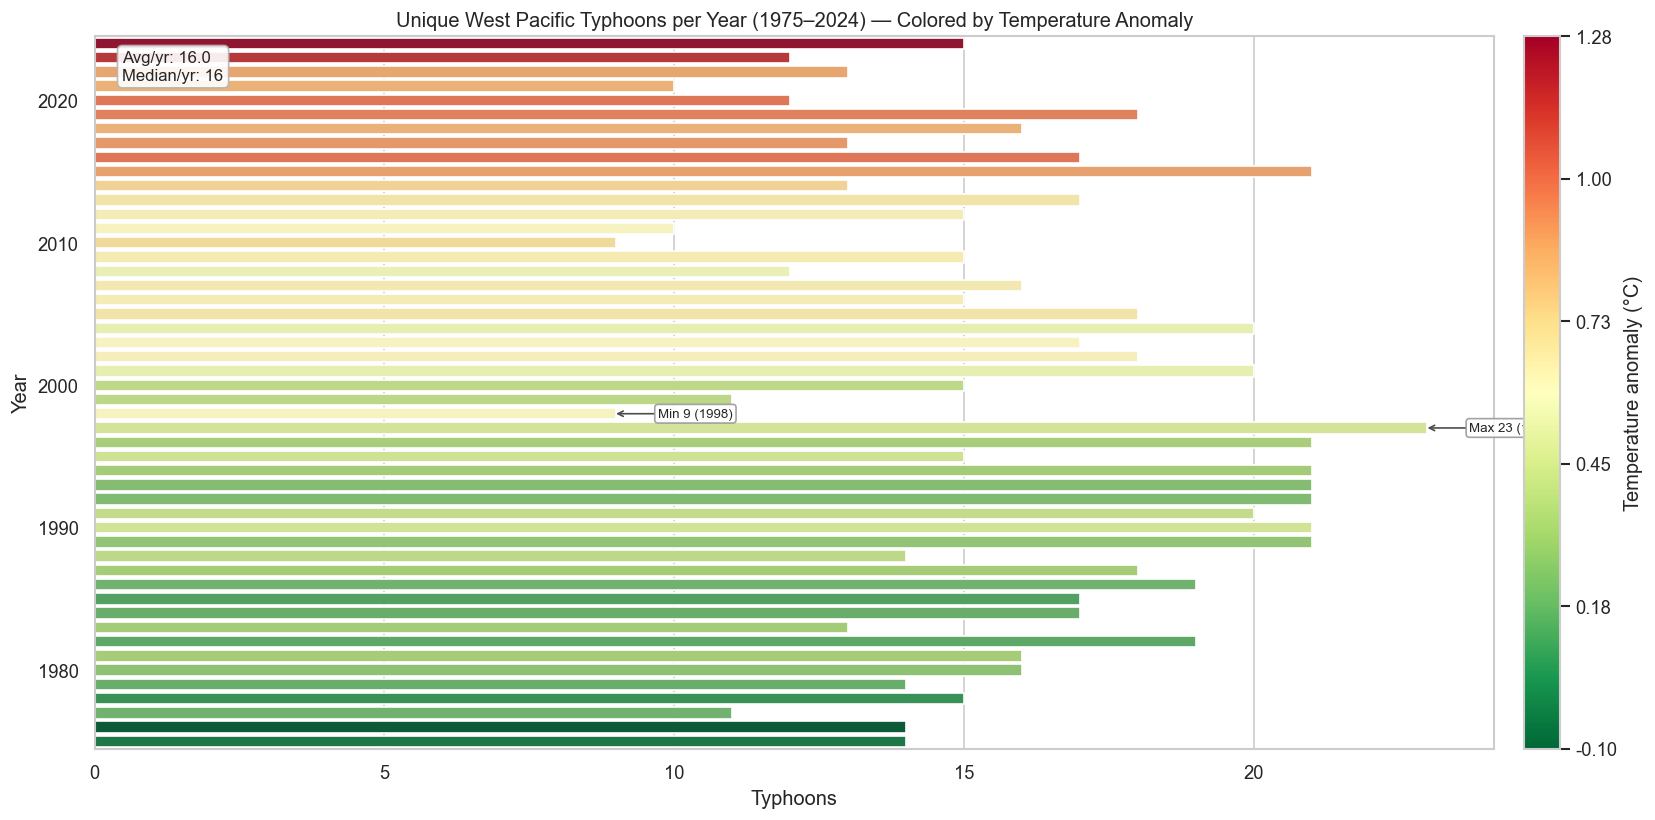

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------- 1) Build annual typhoon counts (1975–2024) --------
# Uses your earlier one-row-per-storm table: `agg_summary` (SEASON, NAME, etc.)
ty_per_year = (
    agg_summary.groupby("SEASON")["SID"].nunique()
               .rename("Typhoon_Count")
               .to_frame()
)

# Make a continuous year index and fill missing with 0 for plotting
year_idx = pd.Index(range(1975, 2025), name="SEASON")
ty_per_year = ty_per_year.reindex(year_idx, fill_value=0).reset_index()
ty_per_year = ty_per_year.rename(columns={"SEASON": "Year"})

# -------- 2) Bring in your temperature anomalies --------
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
temp_df = pd.read_csv(url).rename(columns=str.strip)

# Use your unsmoothed series (same field you used before)
temp_map = temp_df.set_index("Year")["No_Smoothing"]
ty_per_year["TempAnom"] = ty_per_year["Year"].map(temp_map)

# -------- 3) Palette mapping: anomaly -> RdYlGn_r color --------
cmap = mpl.colormaps["RdYlGn_r"]   # green=cool, red=warm
vmin = float(np.nanmin(ty_per_year["TempAnom"]))
vmax = float(np.nanmax(ty_per_year["TempAnom"]))
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

palette = {
    int(y): (0.8, 0.8, 0.8) if not np.isfinite(t) else cmap(norm(t))
    for y, t in zip(ty_per_year["Year"], ty_per_year["TempAnom"])
}

# -------- 4) Plot (Seaborn barplot, horizontal) --------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=ty_per_year.sort_values("Year"),
    x="Typhoon_Count",
    y="Year",
    hue="Year",               # one hue per year so we can inject the palette
    palette=palette,
    dodge=False,
    legend=False,
    errorbar=None,
    orient="h",
    ax=ax
)

ax.set_title("Unique West Pacific Typhoons per Year (1975–2024) — Colored by Temperature Anomaly")
ax.set_xlabel("Typhoons")
ax.set_ylabel("Year")
ax.set_xlim(left=0)

# Put recent years at the top like your hurricanes slide
ax.invert_yaxis()

# Y ticks every 10 years starting 1980
yrs = ty_per_year["Year"].tolist()
tick_pos = [i for i, yr in enumerate(yrs) if (yr >= 1980 and yr % 10 == 0)]
ax.set_yticks(tick_pos)
ax.set_yticklabels([str(yrs[i]) for i in tick_pos])
ax.tick_params(axis="y", which="major", length=6, width=1)

# -------- 5) Stats and annotations (avg/median + min/max) --------
avg_val = ty_per_year["Typhoon_Count"].mean()
med_val = ty_per_year["Typhoon_Count"].median()
ax.text(
    0.02, 0.98, f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9)
)

counts = ty_per_year["Typhoon_Count"].to_numpy()
years_s = ty_per_year["Year"].to_numpy()
imax = int(np.argmax(counts))
imin = int(np.argmin(counts))

bar_max = ax.patches[imax]
bar_min = ax.patches[imin]

x_max = bar_max.get_x() + bar_max.get_width()
y_maxc = bar_max.get_y() + bar_max.get_height()/2
x_min = bar_min.get_x() + bar_min.get_width()
y_minc = bar_min.get_y() + bar_min.get_height()/2

xlo, xhi = ax.get_xlim()
xpad = 0.03 * (xhi - xlo)

ax.annotate(
    f"Max {counts[imax]:.0f} ({int(years_s[imax])})",
    xy=(x_max, y_maxc), xytext=(x_max + xpad, y_maxc),
    ha="left", va="center", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1, color="0.3", shrinkA=0, shrinkB=0)
)
ax.annotate(
    f"Min {counts[imin]:.0f} ({int(years_s[imin])})",
    xy=(x_min, y_minc), xytext=(x_min + xpad, y_minc),
    ha="left", va="center", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1, color="0.3", shrinkA=0, shrinkB=0)
)

# -------- 6) Colorbar for temperature anomaly --------
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.045)
cbar.set_label("Temperature anomaly (°C)")
cbar.set_ticks(np.linspace(vmin, vmax, 6))
cbar.set_ticklabels([f"{t:.2f}" for t in np.linspace(vmin, vmax, 6)])

plt.tight_layout()
plt.show()



In [17]:
rho = storms[["Category","TempAnom"]].corr(method="spearman").iloc[0,1]
tau = storms[["Category","TempAnom"]].corr(method="kendall").iloc[0,1]
print(f"Spearman ρ = {rho:.3f}, Kendall τ = {tau:.3f}")


Spearman ρ = 0.141, Kendall τ = 0.105


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1) Storm-level frame with Year and Category ----------
storms = agg_summary.rename(columns={"SEASON":"Year"})[
    ["SID","NAME","Year","max_usa_sshs","max_usa_wind","max_wmo_wind"]
].copy()

def ss_cat(k):
    if pd.isna(k): return np.nan
    k=float(k)
    return 5 if k>=137 else 4 if k>=113 else 3 if k>=96 else 2 if k>=83 else 1 if k>=64 else 0

cat = storms["max_usa_sshs"].copy()
mask = cat.isna()
cat.loc[mask] = storms.loc[mask,"max_usa_wind"].map(ss_cat)
mask = cat.isna()
cat.loc[mask] = storms.loc[mask,"max_wmo_wind"].map(ss_cat)

storms["Category"] = cat
storms["Major"]    = (storms["Category"] >= 3).astype(int)
storms = storms.query("1975 <= Year <= 2024")

# ---------- 2) Annual counts ----------
annual = (
    storms.groupby("Year")
          .agg(All=("SID","nunique"),
               Major=("Major","sum"))
          .reset_index()
)

# Fill missing years with 0
yr = pd.DataFrame({"Year": np.arange(1975, 2025)})
annual = yr.merge(annual, on="Year", how="left").fillna(0)
annual[["All","Major"]] = annual[["All","Major"]].astype(int)

# ---------- 3) Five-year windows & averages ----------
def window_label(y):
    s = 1975 + 5*((y-1975)//5)
    return f"{s}–{s+4}"

annual["Window"] = annual["Year"].apply(window_label)
five_avg = (annual.groupby("Window", as_index=False)
                  .agg(All=("All","mean"), Major=("Major","mean")))
five_avg["NonMajor"] = five_avg["All"] - five_avg["Major"]

# ---------- 4) Plot (stacked bars) ----------
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(five_avg)); w = 0.75

c_major = "#F4C20D"   # Category 3+ (yellow)
c_rest  = "#2AA198"   # All Typhoons (teal)

ax.bar(x, five_avg["NonMajor"], width=w, color=c_rest, label="All Typhoons")
ax.bar(x, five_avg["Major"],    width=w, color=c_major, bottom=five_avg["NonMajor"], label="Category 3+")

ax.set_title("5 Year Averages — WEST PACIFIC TYPHOONS", fontsize=18, weight="bold", pad=12)
ax.set_ylabel("Average per year")
ax.set_xticks(x, five_avg["Window"])
ax.set_ylim(0, max(8, five_avg["All"].max()*1.15))
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="upper left")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()


NameError: name 'agg_summary' is not defined

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Input expected ----------
# agg_summary: one row per storm with columns:
#   SEASON, SID, max_usa_sshs, max_usa_wind, max_wmo_wind

# --- 1) Build Category and flags (Cat ≥3 = "Major") ---
storms = agg_summary.rename(columns={"SEASON": "Year"})[
    ["SID","NAME","Year","max_usa_sshs","max_usa_wind","max_wmo_wind"]
].copy()

def ss_cat(k):
    if pd.isna(k): return np.nan
    k=float(k)
    return 5 if k>=137 else 4 if k>=113 else 3 if k>=96 else 2 if k>=83 else 1 if k>=64 else 0

cat = storms["max_usa_sshs"].copy()
m = cat.isna()
cat.loc[m] = storms.loc[m, "max_usa_wind"].map(ss_cat)
m = cat.isna()
cat.loc[m] = storms.loc[m, "max_wmo_wind"].map(ss_cat)

storms["Category"] = cat
storms["Major"]    = (storms["Category"] >= 3).astype(int)
storms = storms.query("1975 <= Year <= 2024")

# --- 2) Annual counts (unique storms per year) ---
annual = (
    storms.groupby("Year")
          .agg(All=("SID","nunique"),
               Major=("Major","sum"))
          .reset_index()
)

# Fill any missing years with 0 so windows are complete
years = pd.DataFrame({"Year": np.arange(1975, 2025)})
annual


NameError: name 'agg_summary' is not defined

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Build Category for each storm (one row per SID already in agg_summary) ----
storms = agg_summary.rename(columns={"SEASON":"Year"})[
    ["SID","NAME","Year","max_usa_sshs","max_usa_wind","max_wmo_wind"]
].copy()

def ss_cat(k):
    if pd.isna(k): return np.nan
    k=float(k)
    return 5 if k>=137 else 4 if k>=113 else 3 if k>=96 else 2 if k>=83 else 1 if k>=64 else 0

cat = storms["max_usa_sshs"].copy()
m = cat.isna()
cat.loc[m] = storms.loc[m,"max_usa_wind"].map(ss_cat)
m = cat.isna()
cat.loc[m] = storms.loc[m,"max_wmo_wind"].map(ss_cat)
storms["Category"] = cat
storms = storms.query("1975 <= Year <= 2024").copy()

# ---- Annual counts: All storms vs Major (Cat ≥3) ----
annual = (storms
          .assign(Major=(storms["Category"]>=3).astype(int))
          .groupby("Year", as_index=False)
          .agg(All=("SID","nunique"), Major=("Major","sum")))

# Fill gaps so the line is continuous
years = pd.DataFrame({"Year": np.arange(1975, 2025)})
annual = years.merge(annual, on="Year", how="left").fillna(0)

# ---- Plot with Seaborn ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11,6))

sns.lineplot(data=annual, x="Year", y="All",   marker="o", linewidth=2, label="All Typhoons")
sns.lineplot(data=annual, x="Year", y="Major", marker="o", linewidth=2, label="Category ≥3")

sns.regplot(data=annual, x="Year", y="All",   scatter=False, order=3, ci=None, color="C0", linestyle="--")
sns.regplot(data=annual, x="Year", y="Major", scatter=False, order=3, ci=None, color="C1", linestyle="--")



plt.title("West Pacific Typhoons per Year (1975–2024)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xlim(1975, 2024)
plt.legend(title="Series")
plt.tight_layout()
plt.show()


NameError: name 'agg_summary' is not defined

In [11]:
sns.regplot(data=annual, x="Year", y="All",   scatter=False, order=3, ci=None, color="C0", linestyle="--")
sns.regplot(data=annual, x="Year", y="Major", scatter=False, order=3, ci=None, color="C1", linestyle="--")



NameError: name 'annual' is not defined

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- Prep ----------
df = merged.copy().sort_values("Year").reset_index(drop=True)

# Columns
col_year = "Year"
col_temp = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find the 5 category columns (prefer hurr_cat_k; fallback Cat_k)
cat_cols = []
for k in range(1, 6):
    if f"hurr_cat_{k}" in df.columns:
        cat_cols.append((k, f"hurr_cat_{k}"))
    elif f"Cat_{k}" in df.columns:
        cat_cols.append((k, f"Cat_{k}"))
    else:
        raise KeyError(f"Missing hurricane category column for Cat {k} (looked for 'hurr_cat_{k}' and 'Cat_{k}').")

# Temperature values for coloring
temp_map = df.set_index(col_year)[col_temp]
plot_years = np.sort(df[col_year].dropna().unique())
temp_vals = temp_map.reindex(plot_years).to_numpy(dtype=float)
vmin, vmax = np.nanmin(temp_vals), np.nanmax(temp_vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (temp_vals - vmin) / rng

cmap = sns.color_palette("RdYlGn_r", as_cmap=True)  # green (cool) -> red (warm)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7))
                 for y, t in zip(plot_years, norm_vals)}

# ---------- Plot (5 facets: Cat 1..5) ----------
sns.set_theme(style="whitegrid")
n_panels = len(cat_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6*n_panels+2, 5), sharey=False)

if n_panels == 1:
    axes = [axes]

for ax, (k, colname) in zip(axes, cat_cols):
    d = df[[col_year, colname]].dropna().rename(columns={col_year: "Year", colname: "Count"})
    d = d[np.isfinite(d["Count"])].sort_values("Year")

    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    # Bars colored by same-year temperature
    colors = [year_to_color[int(y)] for y in years]
    ax.bar(x, counts, color=colors, edgecolor="none")

    # Trend line (fit vs positions so it aligns with bars)
    if len(x) >= 2 and np.isfinite(counts).sum() >= 2:
        m, b = np.polyfit(x.astype(float), counts, 1)
        y_hat = m * x + b
        ax.plot(x, y_hat, color="gray", lw=1.0, label="Trend")
    else:
        m = np.nan

    # Titles/labels
    ax.set_title(f"U.S. Hurricanes — Category {k} (1975+)", pad=10)
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    ax.set_ylim(bottom=0)

    # Decade ticks (show real years while x uses positions)
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")

    # Stats box (top-left)
    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(0.02, 0.96,
            f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}\nSlope: {m:+.2f}/yr",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95))

# Shared colorbar for temperature anomaly
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, fraction=0.05)
cbar.set_label("Temperature anomaly (°C)")
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.tight_layout()
plt.show()


NameError: name 'merged' is not defined

In [15]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- Prep ----------
df = merged.copy().sort_values("Year").reset_index(drop=True)

col_year = "Year"
col_temp = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find category columns (prefer hurr_cat_k)
cat_cols = []
for k in range(1, 6):
    if f"hurr_cat_{k}" in df.columns:
        cat_cols.append((k, f"hurr_cat_{k}"))
    elif f"Cat_{k}" in df.columns:
        cat_cols.append((k, f"Cat_{k}"))
    else:
        raise KeyError(f"Missing hurricane category column for Cat {k}.")

# Temperature → colors
temp_map  = df.set_index(col_year)[col_temp]
plot_years = np.sort(df[col_year].dropna().unique())
vals = temp_map.reindex(plot_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (vals - vmin) / rng
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7,0.7,0.7))
                 for y, t in zip(plot_years, norm_vals)}

sns.set_theme(style="whitegrid")

# ---------- Figure: 2 rows × 4 cols (last col = colorbar), 3 axes on top, 2 on bottom ----------
fig = plt.figure(figsize=(16, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1, 1, 1, 0.05])

# Panel slots for 5 categories
ax_positions = [gs[0,0], gs[0,1], gs[0,2], gs[1,0], gs[1,1]]  # 3 top, 2 bottom
axes = [fig.add_subplot(pos) for pos in ax_positions]

# ----- Draw each category panel -----
for ax, (k, colname) in zip(axes, cat_cols):
    d = (df[[col_year, colname]]
         .dropna()
         .rename(columns={col_year:"Year", colname:"Count"})
         .sort_values("Year"))
    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    # Colored bars by temperature
    ax.bar(x, counts, color=[year_to_color[int(y)] for y in years], edgecolor="none")

    # Linear trend (fit to bar positions so line aligns with bars)
    if len(x) >= 2 and np.isfinite(counts).sum() >= 2:
        m, b = np.polyfit(x.astype(float), counts, 1)
        y_hat = m * x + b
        ax.plot(x, y_hat, color="black", lw=1.6)
    else:
        m = np.nan

    # Labels, ticks, limits
    ax.set_title(f"U.S. Hurricanes — Category {k} (1975+)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)

    # Stats box
    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(0.02, 0.96,
            f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}\nSlope: {m:+.2f}/yr",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95))

# Hide the unused (bottom-right) slot if you want (gs[1,2]) — not created above.

# Shared colorbar in the last column (spans both rows)
cax = fig.add_subplot(gs[:, 3])
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Temperature anomaly (°C)")
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.show()


NameError: name 'merged' is not defined

In [17]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress  # for slope, p-value, r, etc.

# ---------- Prep ----------
df = merged.copy().sort_values("Year").reset_index(drop=True)

col_year = "Year"
col_temp = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find hurricane category columns
cat_cols = []
for k in range(1, 6):
    if f"hurr_cat_{k}" in df.columns:
        cat_cols.append((k, f"hurr_cat_{k}"))
    elif f"Cat_{k}" in df.columns:
        cat_cols.append((k, f"Cat_{k}"))
    else:
        raise KeyError(f"Missing hurricane category column for Cat {k}.")

# Temperature → colors
temp_map  = df.set_index(col_year)[col_temp]
plot_years = np.sort(df[col_year].dropna().unique())
vals = temp_map.reindex(plot_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (vals - vmin) / rng
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7,0.7,0.7))
                 for y, t in zip(plot_years, norm_vals)}

sns.set_theme(style="whitegrid")

# ---------- Figure: 3 top, 2 bottom, colorbar at far right ----------
fig = plt.figure(figsize=(16, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1, 1, 1, 0.05])

ax_positions = [gs[0,0], gs[0,1], gs[0,2], gs[1,0], gs[1,1]]
axes = [fig.add_subplot(pos) for pos in ax_positions]

for ax, (k, colname) in zip(axes, cat_cols):
    d = (df[[col_year, colname]]
         .dropna()
         .rename(columns={col_year:"Year", colname:"Count"})
         .sort_values("Year"))
    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    # Bars colored by temperature
    ax.bar(x, counts, color=[year_to_color[int(y)] for y in years], edgecolor="none")

    # Linear trend using bar positions (so it aligns visually)
    m = np.nan; p = np.nan; r2 = np.nan
    mask = np.isfinite(counts)
    if mask.sum() >= 2 and np.nanstd(counts) > 0:
        res = linregress(x[mask].astype(float), counts[mask].astype(float))
        m, b, p, r2 = res.slope, res.intercept, res.pvalue, res.rvalue**2
        y_hat = m * x + b
        ax.plot(x, y_hat, color="gray", lw=1.6)

    # Labels & ticks
    ax.set_title(f"U.S. Hurricanes — Category {k} (1975+)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)

    # Stats box with slope, p-value, R², avg, median
    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(
        0.02, 0.96,
        f"Avg/yr: {avg_val:,.1f}\n"
        f"Median/yr: {med_val:,.0f}\n"
        f"Slope: {m:+.2f}/yr\n"
        f"p-value: {p:.3g}\n"
        f"R²: {r2:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95)
    )

# Shared colorbar on the right
cax = fig.add_subplot(gs[:, 3])
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Temperature anomaly (°C)")
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.show()


NameError: name 'merged' is not defined

In [19]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ===== Prep from merged =====
df = merged.copy().sort_values("Year").reset_index(drop=True)

year_col = "Year"
temp_col = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find tornado magnitude columns (robust to your naming)
mag_cols = []
for k in range(6):  # 0..5
    if f"torn_mag{k}" in df.columns:
        mag_cols.append((k, f"torn_mag{k}"))
    elif f"Mag{k}" in df.columns:
        mag_cols.append((k, f"Mag{k}"))
    else:
        raise KeyError(f"Missing tornado magnitude column for Mag {k}.")

# Temperature → color per year
temp_map = df.set_index(year_col)[temp_col]
plot_years = np.sort(df[year_col].dropna().unique())
vals = temp_map.reindex(plot_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (vals - vmin) / rng
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7))
                 for y, t in zip(plot_years, norm_vals)}

sns.set_theme(style="whitegrid")

# ===== Figure: 2 rows × 3 cols, shared colorbar on right =====
fig = plt.figure(figsize=(18, 9), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1, 1, 1, 0.05])

axes = [
    fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
    fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2]),
]

for ax, (k, colname) in zip(axes, mag_cols):
    d = (df[[year_col, colname]]
         .dropna()
         .rename(columns={year_col:"Year", colname:"Count"})
         .sort_values("Year"))
    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    # Bars colored by temperature
    ax.bar(x, counts, color=[year_to_color[int(y)] for y in years], edgecolor="none")

    # Linear trend line (fit on bar positions so line aligns with bars)
    m = np.nan; p = np.nan; r2 = np.nan
    mask = np.isfinite(counts)
    if mask.sum() >= 2 and np.nanstd(counts[mask]) > 0:
        res = linregress(x[mask].astype(float), counts[mask].astype(float))
        m, b, p, r2 = res.slope, res.intercept, res.pvalue, res.rvalue**2
        y_hat = m * x + b
        ax.plot(x, y_hat, color="gray", lw=1.6)

    # Labels & ticks
    ax.set_title(f"U.S. Tornadoes — Magnitude {k} (1975+)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)

    # Stats box (Avg, Median, Slope, p, R²)
    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(
        0.02, 0.96,
        f"Avg/yr: {avg_val:,.1f}\n"
        f"Median/yr: {med_val:,.0f}\n"
        f"Slope: {m:+.2f}/yr\n"
        f"p-value: {p:.3g}\n"
        f"R²: {r2:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95)
    )

# Shared colorbar (temperature anomaly)
cax = fig.add_subplot(gs[:, 3])
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Temperature anomaly (°C)")
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.show()


NameError: name 'merged' is not defined

In [21]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ===== Prep from merged =====
df = merged.copy().sort_values("Year").reset_index(drop=True)

year_col = "Year"
temp_col = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find typhoon SSHS category columns (robust to your naming)
typh_cols = []
for k in range(6):  # 0..5
    # prefer prefixed columns
    if f"typh_cat{k}" in df.columns:
        typh_cols.append((k, f"typh_cat{k}"))
    # fallback to unprefixed (if you kept them that way)
    elif f"Cat{k}" in df.columns:
        typh_cols.append((k, f"Cat{k}"))
    else:
        raise KeyError(f"Missing typhoon category column for Cat {k}.")

# Temperature → color per year
temp_map = df.set_index(year_col)[temp_col]
plot_years = np.sort(df[year_col].dropna().unique())
vals = temp_map.reindex(plot_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (vals - vmin) / rng
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7))
                 for y, t in zip(plot_years, norm_vals)}

sns.set_theme(style="whitegrid")

# ===== Figure: 2 rows × 3 cols, shared colorbar on right =====
fig = plt.figure(figsize=(18, 9), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1, 1, 1, 0.05])

axes = [
    fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
    fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2]),
]

for ax, (k, colname) in zip(axes, typh_cols):
    d = (df[[year_col, colname]]
         .dropna()
         .rename(columns={year_col:"Year", colname:"Count"})
         .sort_values("Year"))
    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    # Bars colored by temperature
    ax.bar(x, counts, color=[year_to_color[int(y)] for y in years], edgecolor="none")

    # Linear trend line (fit on bar positions so line aligns with bars)
    m = np.nan; p = np.nan; r2 = np.nan
    mask = np.isfinite(counts)
    if mask.sum() >= 2 and np.nanstd(counts[mask]) > 0:
        res = linregress(x[mask].astype(float), counts[mask].astype(float))
        m, b, p, r2 = res.slope, res.intercept, res.pvalue, res.rvalue**2
        y_hat = m * x + b
        ax.plot(x, y_hat, color="black", lw=1.6)

    # Labels & ticks
    ax.set_title(f"West Pacific Typhoons — SSHS Cat {k} (1975+)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)

    # Stats box (Avg, Median, Slope, p, R²)
    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(
        0.02, 0.96,
        f"Avg/yr: {avg_val:,.1f}\n"
        f"Median/yr: {med_val:,.0f}\n"
        f"Slope: {m:+.2f}/yr\n"
        f"p-value: {p:.3g}\n"
        f"R²: {r2:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95)
    )

# Shared colorbar (temperature anomaly)
cax = fig.add_subplot(gs[:, 3])
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Temperature anomaly (°C)")
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

plt.show()


NameError: name 'merged' is not defined